# WG-Netz Winterthur — Study Analysis

This notebook provides a full qualitative and quantitative analysis of the **WG-Netz Winterthur** online study.

> **Note on vote tracking:** The study ran through the `AnswerSearch` → `Closing` phases only (no formal `Voting` phase). User support is therefore tracked via **subscriptions** (`subscription_count` on proposals, `subscribe`/`unsubscribe` events in action_logs), not `support_count` which remains 0 for all proposals.

**Sections:**
1. Data Loading & Preprocessing
2. Study Overview & Timeline
3. User Engagement Analysis
4. System Interaction Patterns
5. Idea Progression & Diversity
6. Subscription Dynamics (vote tracking)
7. Proposal Engagement Funnel
8. Phase-Aware Analysis
9. Final Outcomes & Consensus
10. Post-Study Survey Analysis

## 1. Data Loading & Preprocessing

In [ ]:
import sys
from pathlib import Path

# Ensure the repository root is on sys.path so `tooling` is importable.
_repo_root = Path.cwd().resolve()
while _repo_root != _repo_root.parent and not (_repo_root / "tooling").exists():
    _repo_root = _repo_root.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json
import os
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# ── Config ──────────────────────────────────────────────────────────────────
csv_dir = _repo_root / "experiment_data" / "human_studies" / "wg_netz_winterthur"
if not csv_dir.exists():
    csv_dir = (Path.cwd() / "../../../experiment_data/human_studies/wg_netz_winterthur").resolve()

# Study start cutoff (real study started July 27 at 19:00 CEST = 17:00 UTC)
CUTOFF = pd.Timestamp("2026-08-06 13:00:00", tz="UTC")

# ── Load CSVs ────────────────────────────────────────────────────────────────
def load_csv(name, **kwargs):
    p = csv_dir / f"{name}.csv"
    if p.exists() and p.stat().st_size > 0:
        return pd.read_csv(p, **kwargs)
    return pd.DataFrame()

df_questions      = load_csv("questions")
df_proposals      = load_csv("proposals")
df_votes          = load_csv("proposal_votes")
df_actions        = load_csv("action_logs")
df_users          = load_csv("users")
df_members        = load_csv("group_members")
df_labels         = load_csv("labels")
df_phases         = load_csv("question_phases")
df_consents       = load_csv("study_consents")
df_views          = load_csv("user_proposal_views")
df_hides          = load_csv("proposal_hides")
df_push           = load_csv("push_notification_log")
df_surveys        = load_csv("post_study_surveys")

# ── Identify & filter admin user ────────────────────────────────────────────
admin_ids = set(df_members.loc[df_members['role'] == 'Admin', 'user'].dropna())
participant_ids = set(df_members.loc[df_members['role'] != 'Admin', 'user'].dropna())
print(f"Admin users (excluded from analysis): {admin_ids}")
print(f"Participant IDs: {len(participant_ids)}")

# ── Parse dates ──────────────────────────────────────────────────────────────
for df, cols in [
    (df_actions,   ['occurred_at', 'created']),
    (df_proposals, ['created']),
    (df_votes,     ['created', 'occurred_at']),
    (df_phases,    ['started_at', 'ended_at']),
    (df_views,     ['first_viewed', 'last_viewed']),
    (df_push,      ['created']),
]:
    for col in cols:
        if not df.empty and col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')

# ── Build label lookup ───────────────────────────────────────────────────────
label_name = dict(zip(df_labels['id'], df_labels['short_name'])) if not df_labels.empty else {}

def get_label(primary_label_id):
    if pd.isna(primary_label_id) or primary_label_id == '':
        return 'Unlabelled'
    return label_name.get(str(primary_label_id), str(primary_label_id)[:12])

df_proposals['label_name'] = df_proposals['primary_label'].apply(get_label)

# ── Apply cutoff & admin filter ──────────────────────────────────────────────
df_actions_all = df_actions.copy()  # keep all for session analysis
df_actions = df_actions[
    (df_actions['occurred_at'] >= CUTOFF) &
    (~df_actions['user'].isin(admin_ids))
].copy()

df_proposals = df_proposals[df_proposals['created'] >= CUTOFF].copy()
df_votes = df_votes[
    (df_votes['created'] >= CUTOFF) &
    (~df_votes['user'].isin(admin_ids))
].copy()

# ── Summary ──────────────────────────────────────────────────────────────────
summary = {
    'questions': len(df_questions),
    'participants': len(participant_ids),
    'proposals': len(df_proposals),
    'vote records': len(df_votes),
    'action logs (post-cutoff, non-admin)': len(df_actions),
    'labels': len(df_labels),
    'question phases': len(df_phases),
    'view records': len(df_views),
    'push notifications': len(df_push),
    'survey responses': len(df_surveys),
}
print("\n=== Data Summary ===")
for k, v in summary.items():
    print(f"  {k:<45} {v}")

# ── Section 11: Build QuestionData for metrics engine ────────────────────────
from tooling.evaluation.extract.pb_extractor import (
    ActionLogRecord, QuestionData, QuestionPhaseRecord, SolutionRecord, VoteRecord,
)

def _json_list(value):
    import json as _json
    if isinstance(value, list):
        return [str(item) for item in value if pd.notna(item)]
    if value is None or value == "" or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, str):
        try:
            parsed = _json.loads(value)
            if isinstance(parsed, list):
                return [str(item) for item in parsed if pd.notna(item)]
        except Exception:
            return [value]
    return []

def _json_object(value):
    import json as _json
    if isinstance(value, dict):
        return value
    if value is None or value == "" or (isinstance(value, float) and pd.isna(value)):
        return {}
    if isinstance(value, str):
        try:
            parsed = _json.loads(value)
            if isinstance(parsed, dict):
                return parsed
        except Exception:
            return {}
    return {}

_question_row = df_questions.iloc[0] if not df_questions.empty else pd.Series(dtype=object)
_question_id = str(_question_row.get("id", ""))
_question_title = str(_question_row.get("title", "WG-Netz Winterthur"))
_focus_quorum = int(_question_row.get("focus_quorum", 0) or 0)

_solutions = []
for _, _row in df_proposals.iterrows():
    _raw_root = _row.get("root_proposal", _row.get("root_solution", _row.get("id", "")))
    _root = str(_raw_root[0] if isinstance(_raw_root, list) and _raw_root else _raw_root or _row.get("id", ""))
    _support = int(_row.get("subscription_count", _row.get("support_count", 0)) or 0)
    _solutions.append(SolutionRecord(
        id=str(_row.get("id", "")),
        title=str(_row.get("title", "") or ""),
        state=str(_row.get("state", "Proposed") or "Proposed"),
        support_count=_support,
        current_score=float(_support),
        is_champion=bool(_row.get("is_champion", False)),
        in_focus=bool(_row.get("in_focus", False)),
        parent_solutions=_json_list(_row.get("parent_proposals", _row.get("parent_solutions", []))),
        root_solution=_root,
        merge_status=str(_row.get("merge_status", "none") or "none"),
        base_parent="",
        created=str(_row.get("created", "") or ""),
        occurred_at=str(_row.get("created", "") or ""),
        absorbed_clusters=[],
        labels=_json_list(_row.get("labels", [])),
        primary_label=str(_row.get("primary_label", "") or ""),
    ))

_votes = []
for _, _row in df_votes.iterrows():
    _votes.append(VoteRecord(
        id=str(_row.get("id", "")),
        solution=str(_row.get("proposal", _row.get("solution", "")) or ""),
        user=str(_row.get("user", "") or ""),
        vote=int(_row.get("vote", 0) or 0),
        created=str(_row.get("created", "") or ""),
        occurred_at=str(_row.get("occurred_at", _row.get("created", "")) or ""),
    ))

_action_logs = []
for _, _row in df_actions.iterrows():
    _action_logs.append(ActionLogRecord(
        id=str(_row.get("id", "")),
        question=str(_row.get("question", _question_id) or _question_id),
        action_type=str(_row.get("action_type", "") or ""),
        target_id=str(_row.get("target_id", "") or ""),
        occurred_at=str(_row.get("occurred_at", _row.get("created", "")) or ""),
        user=str(_row.get("user", "") or ""),
        metadata_json=_json_object(_row.get("metadata_json", {})),
    ))

_phases = []
for _, _row in df_phases.iterrows():
    _phases.append(QuestionPhaseRecord(
        id=str(_row.get("id", "")),
        phase_name=str(_row.get("phase_name", "") or ""),
        started_at=str(_row.get("started_at", "") or ""),
        ended_at=str(_row.get("ended_at", "") or ""),
    ))

_label_lookup = dict(zip(df_labels["id"], df_labels["short_name"])) if not df_labels.empty else {}

question_data = QuestionData(
    question_id=_question_id,
    title=_question_title,
    focus_quorum=_focus_quorum,
    solutions=_solutions,
    votes=_votes,
    action_logs=_action_logs,
    phases=_phases,
    label_names=_label_lookup,
)
print(f"question_data built: {len(_solutions)} proposals, {len(_votes)} votes, {len(_action_logs)} action logs")

# ── Section 11 setup: metrics imports ────────────────────────────────────────
from tooling.evaluation.metrics.metrics import (
    compute_behavioral_metrics,
    compute_label_metrics,
    compute_temporal_metrics,
)
from tooling.evaluation.plots.plot_metrics import (
    plot_label_distribution,
    plot_temporal_convergence,
)





Admin users (excluded from analysis): {'de13859e1d6aea12'}
Participant IDs: 16

=== Data Summary ===
  questions                                     2
  participants                                  16
  proposals                                     29
  vote records                                  64
  action logs (post-cutoff, non-admin)          2567
  labels                                        11
  question phases                               10
  view records                                  200
  push notifications                            293
  survey responses                              3
question_data built: 29 proposals, 64 votes, 2567 action logs


## 2. Study Overview & Timeline

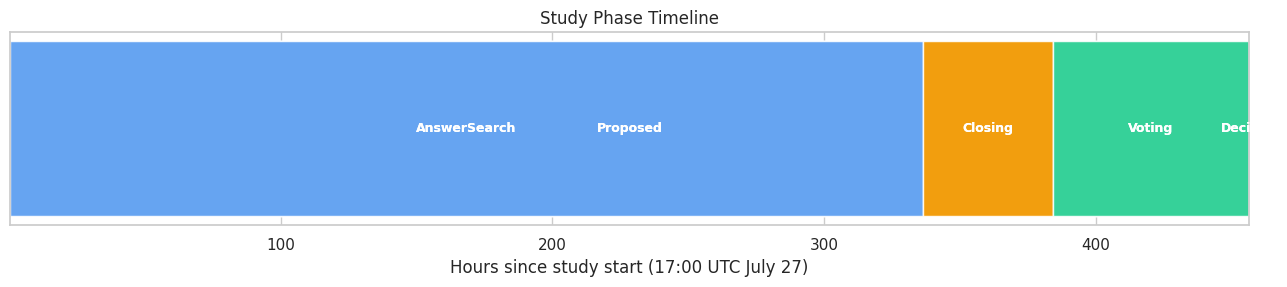


=== Study Overview ===
  Question: Wie definieren wir das WG-Netz und ihre Rolle in Winterthur?
  Participants (excl. admin): 16
  Consented: 12 / 16


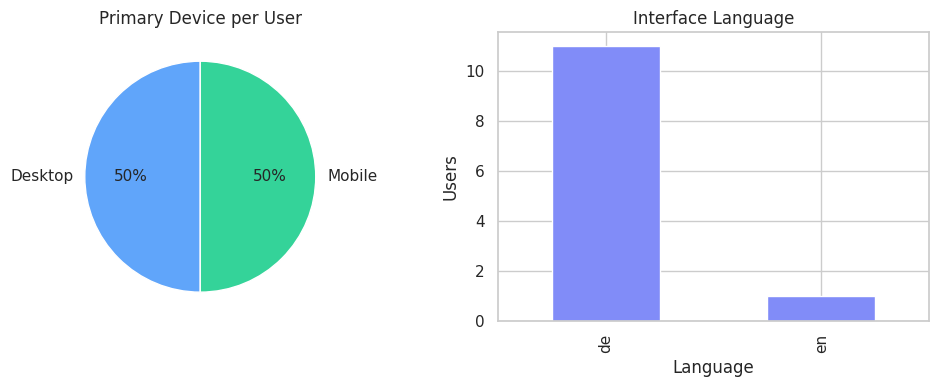

In [ ]:
# ── Phase timeline Gantt ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3))

phase_colors = {'Proposed': '#94a3b8', 'AnswerSearch': '#60a5fa', 'Closing': '#f59e0b', 'Voting': '#34d399'}

if not df_phases.empty:
    df_phases_sorted = df_phases.sort_values('started_at')
    max_end = df_phases_sorted['ended_at'].max()
    if pd.isna(max_end):
        max_end = pd.Timestamp.now(tz='UTC')

    for i, (_, row) in enumerate(df_phases_sorted.iterrows()):
        start = row['started_at']
        end = row['ended_at'] if not pd.isna(row['ended_at']) else max_end
        color = phase_colors.get(row['phase_name'], '#a78bfa')
        ax.barh(0, (end - start).total_seconds() / 3600, left=(start - CUTOFF).total_seconds() / 3600,
                color=color, height=0.5, alpha=0.85, label=row['phase_name'])
        mid = start + (end - start) / 2
        ax.text((mid - CUTOFF).total_seconds() / 3600, 0, row['phase_name'],
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')

ax.set_xlabel('Hours since study start (17:00 UTC July 27)')
ax.set_yticks([])
ax.set_title('Study Phase Timeline')
plt.tight_layout()
plt.show()

# ── Key stats table ──────────────────────────────────────────────────────────
print("\n=== Study Overview ===")
q = df_questions.iloc[0] if not df_questions.empty else {}
print(f"  Question: {q.get('title', 'N/A')}")
print(f"  Participants (excl. admin): {len(participant_ids)}")
print(f"  Consented: {len(df_consents)} / {len(participant_ids)}")

# ── Device breakdown ─────────────────────────────────────────────────────────
session_logs = df_actions_all[df_actions_all['action_type'] == 'session_start'].copy()
session_logs = session_logs[~session_logs['user'].isin(admin_ids)]

if not session_logs.empty:
    def parse_mobile(meta):
        try:
            d = json.loads(meta) if isinstance(meta, str) else meta
            return 'Mobile' if d.get('isMobile') else 'Desktop'
        except:
            return 'Unknown'
    session_logs['device'] = session_logs['metadata_json'].apply(parse_mobile)
    device_counts = session_logs.groupby('user')['device'].agg(lambda x: 'Mobile' if 'Mobile' in x.values else 'Desktop')

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    device_counts.value_counts().plot.pie(ax=axes[0], autopct='%1.0f%%', startangle=90,
                                           colors=['#60a5fa', '#34d399'], title='Primary Device per User')
    axes[0].set_ylabel('')

    if not df_users.empty and 'language' in df_users.columns:
        df_users['language'].value_counts().plot.bar(ax=axes[1], color='#818cf8')
        axes[1].set_title('Interface Language')
        axes[1].set_xlabel('Language')
        axes[1].set_ylabel('Users')

    plt.tight_layout()
    plt.show()

## 3. User Engagement Analysis

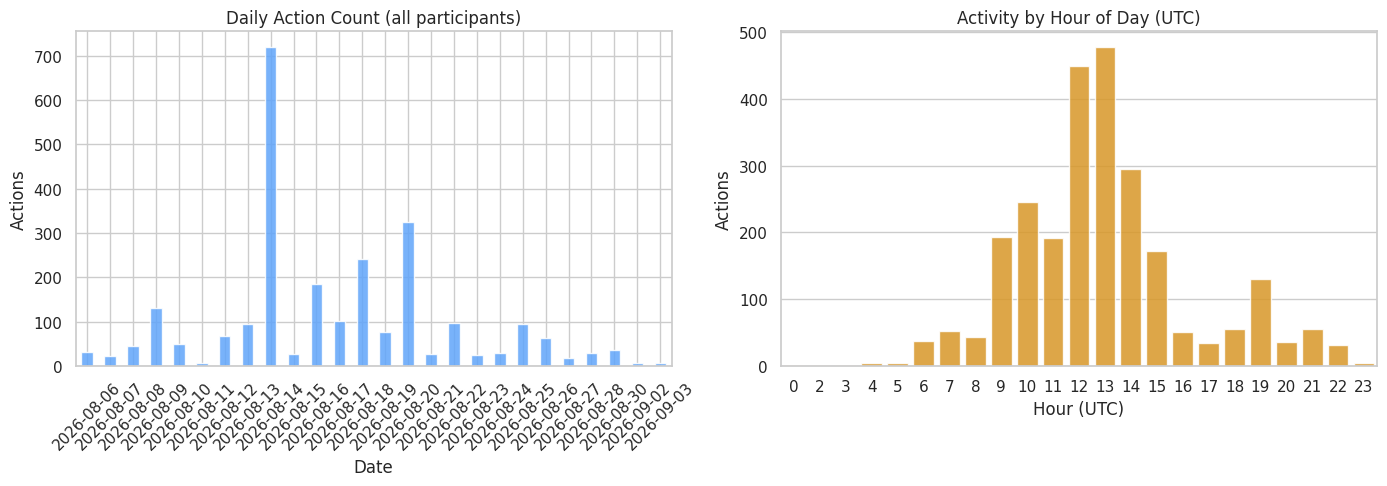

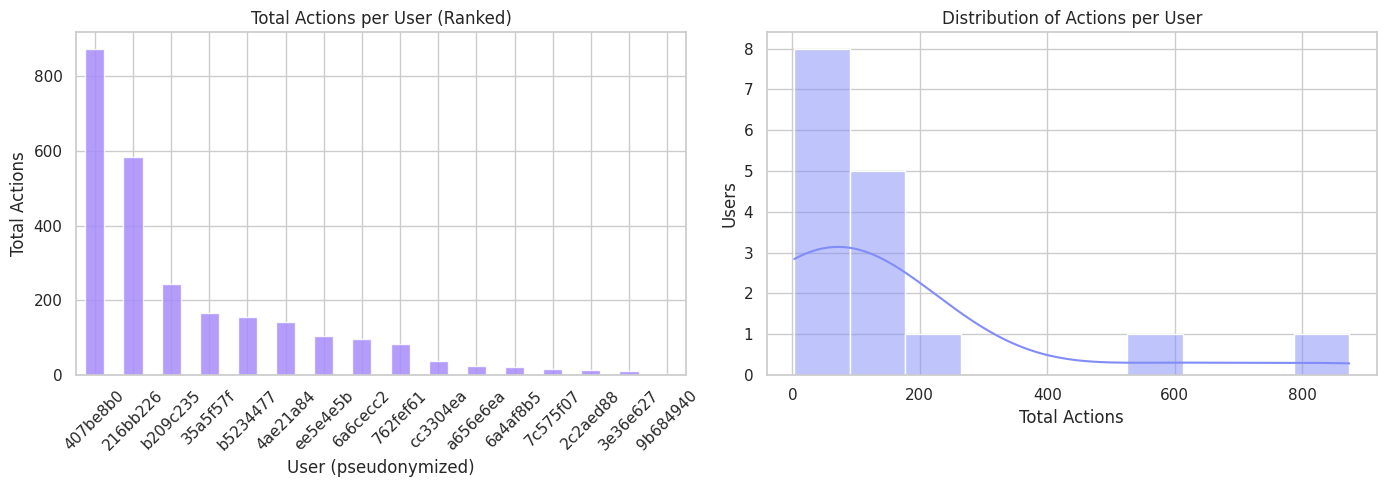


Actions per user — mean: 160.4, median: 88, max: 874


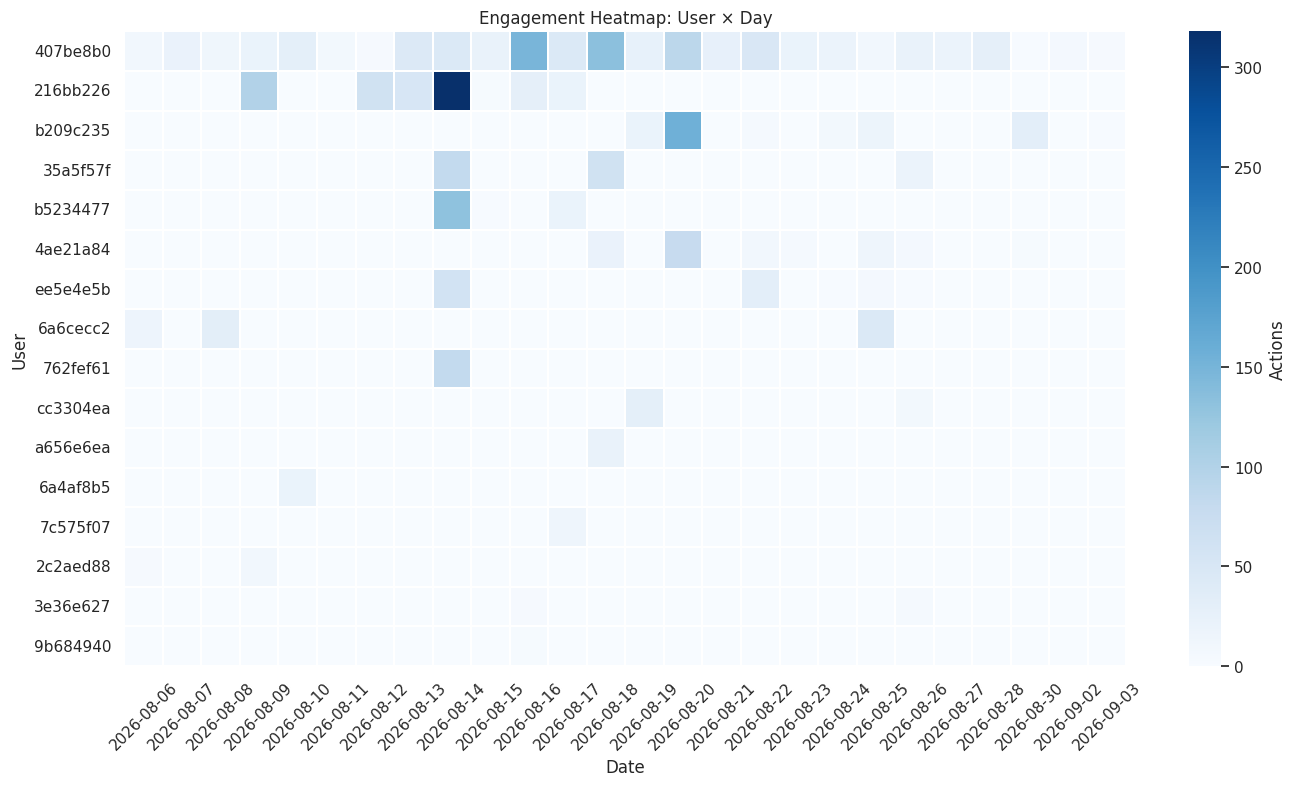


Sessions per user — mean: 4.3, total: 26


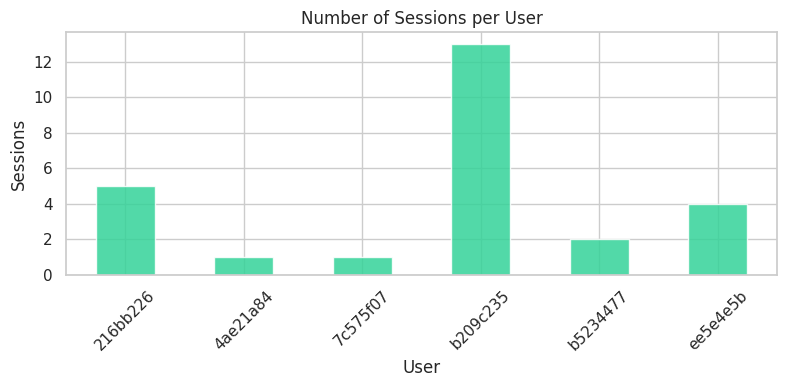

In [ ]:
# ── 3.1 Activity over time ────────────────────────────────────────────────────
df_actions['date'] = df_actions['occurred_at'].dt.date
df_actions['hour'] = df_actions['occurred_at'].dt.hour

daily = df_actions.groupby('date').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
daily.plot(kind='bar', ax=axes[0], color='#60a5fa', alpha=0.85)
axes[0].set_title('Daily Action Count (all participants)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Actions')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df_actions, x='hour', ax=axes[1], color='#f59e0b', alpha=0.85)
axes[1].set_title('Activity by Hour of Day (UTC)')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Actions')

plt.tight_layout()
plt.show()

# ── 3.2 Per-user engagement ────────────────────────────────────────────────────
user_action_counts = df_actions['user'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ranked bar
user_action_counts.plot(kind='bar', ax=axes[0], color='#a78bfa', alpha=0.85)
axes[0].set_title('Total Actions per User (Ranked)')
axes[0].set_xlabel('User (pseudonymized)')
axes[0].set_ylabel('Total Actions')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xticklabels([u[:8] for u in user_action_counts.index])

# Histogram
sns.histplot(user_action_counts, bins=10, kde=True, ax=axes[1], color='#818cf8')
axes[1].set_title('Distribution of Actions per User')
axes[1].set_xlabel('Total Actions')
axes[1].set_ylabel('Users')

plt.tight_layout()
plt.show()

print(f"\nActions per user — mean: {user_action_counts.mean():.1f}, "
      f"median: {user_action_counts.median():.0f}, "
      f"max: {user_action_counts.max()}")

# ── 3.3 Engagement heatmap: user × day ────────────────────────────────────────
if len(df_actions) > 0:
    heatmap_data = df_actions.groupby(['user', 'date']).size().unstack(fill_value=0)
    heatmap_data.index = [i[:8] for i in heatmap_data.index]  # shorten IDs
    # Sort by total activity
    heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(14, max(4, len(heatmap_data) * 0.5)))
    sns.heatmap(heatmap_data, ax=ax, cmap='Blues', linewidths=0.3,
                cbar_kws={'label': 'Actions'})
    ax.set_title('Engagement Heatmap: User × Day')
    ax.set_xlabel('Date')
    ax.set_ylabel('User')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

# ── 3.4 Session analysis ───────────────────────────────────────────────────────
sessions = df_actions[df_actions['action_type'] == 'session_start']
if not sessions.empty:
    sess_per_user = sessions.groupby('user').size()
    print(f"\nSessions per user — mean: {sess_per_user.mean():.1f}, total: {sess_per_user.sum()}")
    fig, ax = plt.subplots(figsize=(8, 4))
    sess_per_user.plot(kind='bar', ax=ax, color='#34d399', alpha=0.85)
    ax.set_title('Number of Sessions per User')
    ax.set_xlabel('User')
    ax.set_ylabel('Sessions')
    ax.set_xticklabels([u[:8] for u in sess_per_user.index], rotation=45)
    plt.tight_layout()
    plt.show()

## 4. System Interaction Patterns

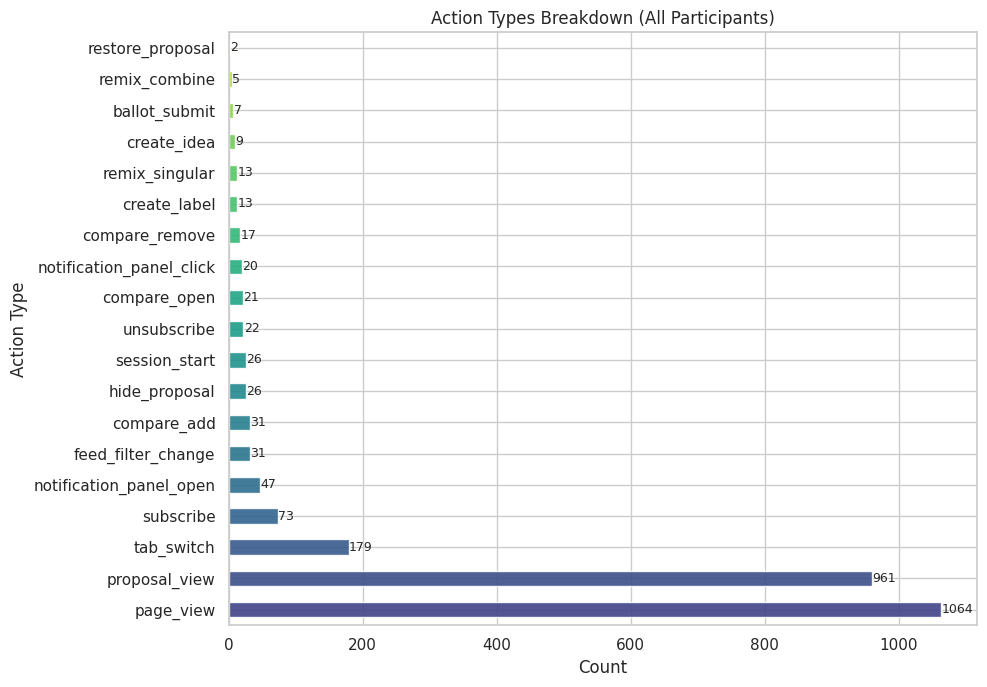

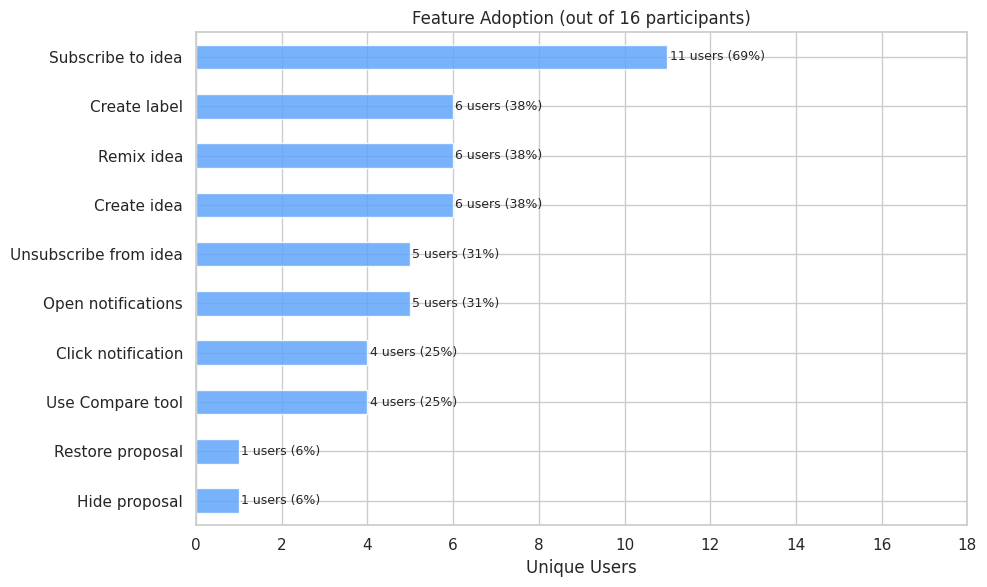

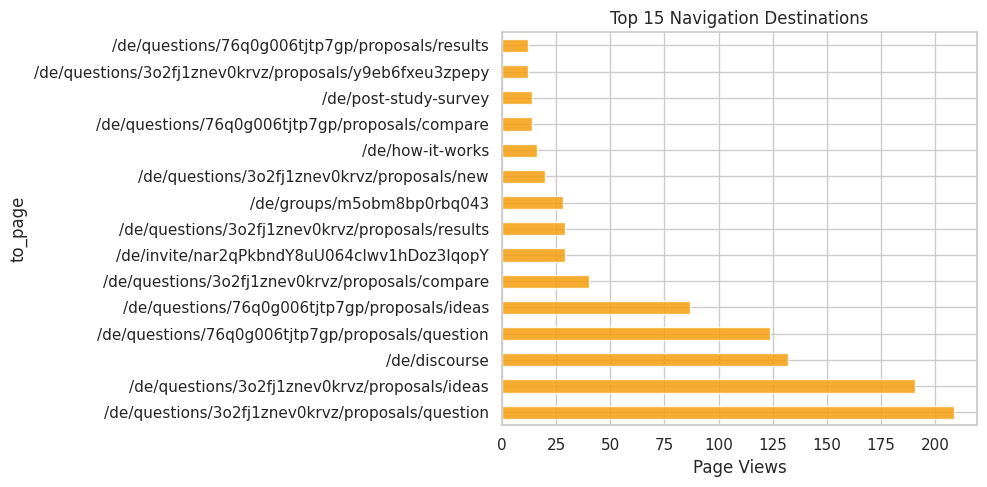

In [ ]:
# ── 4.1 Action type breakdown ─────────────────────────────────────────────────
action_counts = df_actions['action_type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(action_counts)))
action_counts.plot(kind='barh', ax=ax, color=colors, alpha=0.9)
ax.set_title('Action Types Breakdown (All Participants)')
ax.set_xlabel('Count')
ax.set_ylabel('Action Type')
# Add count labels
for i, (v) in enumerate(action_counts):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

# ── 4.2 Feature adoption ──────────────────────────────────────────────────────
feature_actions = {
    'Subscribe to idea': 'subscribe',
    'Unsubscribe from idea': 'unsubscribe',
    'Create idea': 'create_idea',
    'Remix idea': 'remix_singular',
    'Create label': 'create_label',
    'Use Compare tool': 'compare_open',
    'Hide proposal': 'hide_proposal',
    'Restore proposal': 'restore_proposal',
    'Open notifications': 'notification_panel_open',
    'Click notification': 'notification_panel_click',
}

# Users who used each feature (unique users)
feature_adoption = {}
for label, atype in feature_actions.items():
    users_who_used = df_actions[df_actions['action_type'] == atype]['user'].nunique()
    feature_adoption[label] = users_who_used

n_participants = len(participant_ids)
adoption_series = pd.Series(feature_adoption).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = adoption_series.plot(kind='barh', ax=ax, color='#60a5fa', alpha=0.85)
for i, v in enumerate(adoption_series):
    pct = v / n_participants * 100
    ax.text(v + 0.05, i, f"{v} users ({pct:.0f}%)", va='center', fontsize=9)
ax.set_xlim(0, n_participants + 2)
ax.set_title(f'Feature Adoption (out of {n_participants} participants)')
ax.set_xlabel('Unique Users')
plt.tight_layout()
plt.show()

# ── 4.3 Top navigation pages ──────────────────────────────────────────────────
page_views = df_actions[df_actions['action_type'] == 'page_view'].copy()
if not page_views.empty:
    def extract_to_page(meta):
        try:
            d = json.loads(meta) if isinstance(meta, str) else meta
            return d.get('to', 'unknown')
        except:
            return 'unknown'
    page_views['to_page'] = page_views['metadata_json'].apply(extract_to_page)
    top_pages = page_views['to_page'].value_counts().head(15)

    fig, ax = plt.subplots(figsize=(10, 5))
    top_pages.plot(kind='barh', ax=ax, color='#f59e0b', alpha=0.85)
    ax.set_title('Top 15 Navigation Destinations')
    ax.set_xlabel('Page Views')
    plt.tight_layout()
    plt.show()

## 5. Idea Progression & Diversity

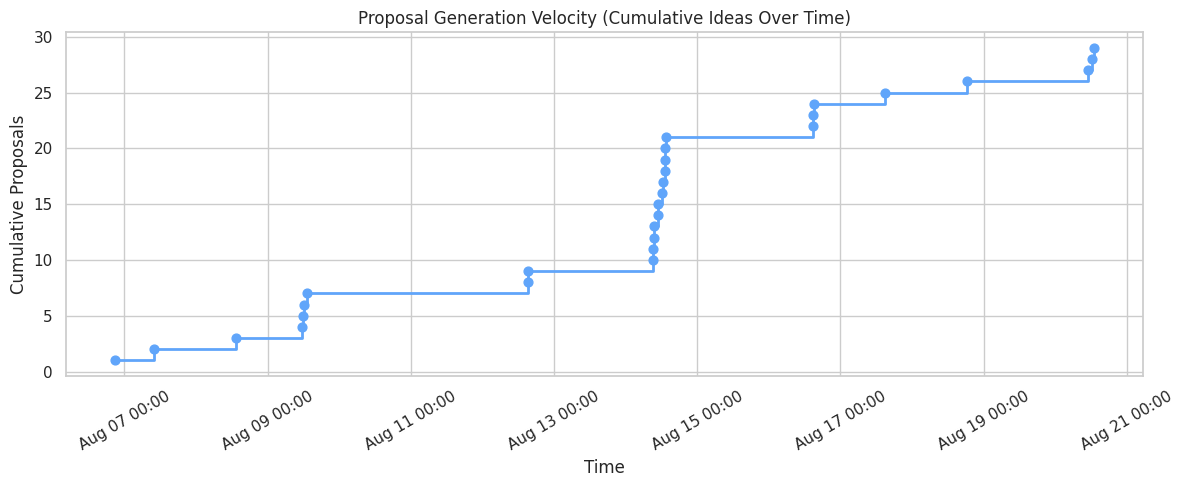

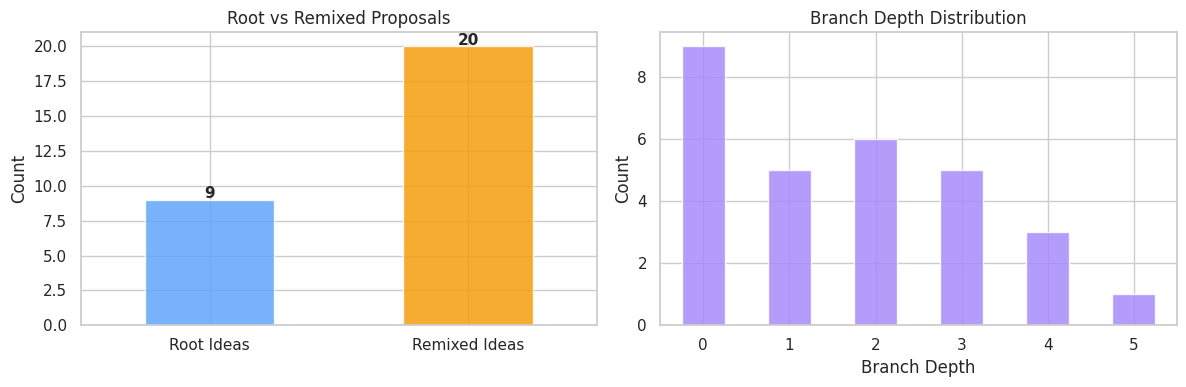

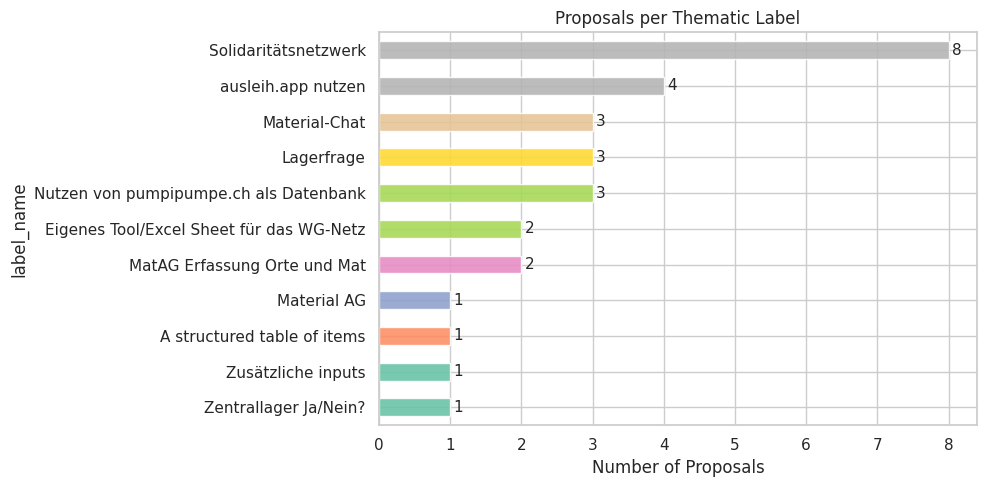

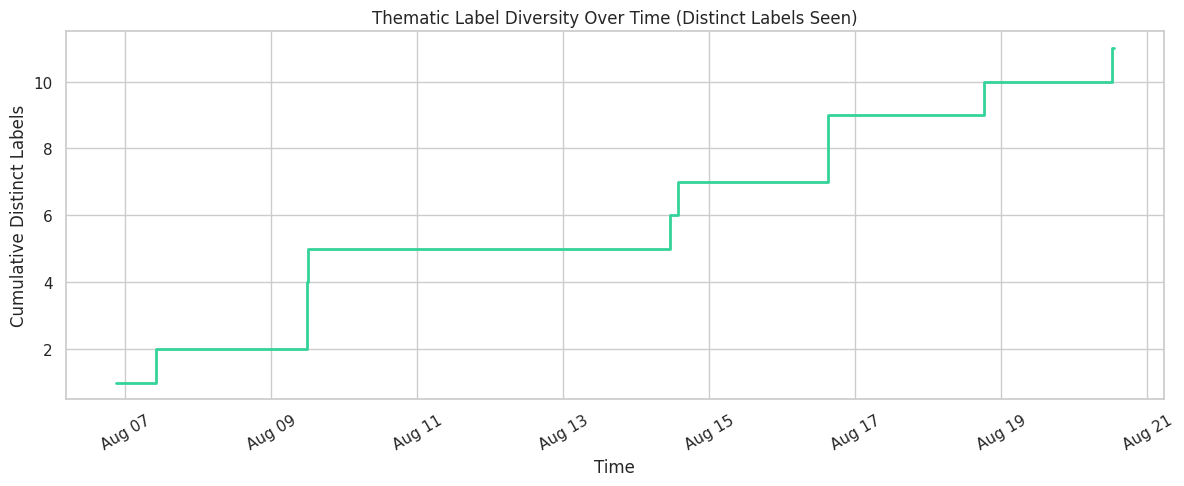


=== All Proposals ===
  [3 subs | ausleih.app nutzen] ausleih.app nutzen [remix of ["2w5teh1hty0mznr", ]
  [3 subs | Solidaritätsnetzwerk] Solidaritätsnetzwerk [remix of ["jm45hx8bajf99lv"]]
  [3 subs | MatAG Erfassung Orte und Mat] Material AG Verwaltet Erfassung von Orten und Mat [remix of ["2k4q9z9tfrakikx", ]
  [3 subs | Zusätzliche inputs] Zusätzliche inputs
  [2 subs | Nutzen von pumpipumpe.ch als Datenbank] Nutzen von pumpipumpe.ch als Datenbank was wo vorhanden ist
  [2 subs | Material-Chat] Im Material-Chat fragen, wenn jemensch was braucht [remix of ["rgjhcdyr8kdvxyz"]]
  [2 subs | Material-Chat] Im Material-Chat fragen, wenn jemensch was braucht [remix of ["px3acjduduouqz6"]]
  [2 subs | ausleih.app nutzen] ausleih.app nutzen
  [2 subs | A structured table of items] A structured table of items
  [2 subs | Solidaritätsnetzwerk] Solidaritätsnetzwerk [remix of ["l6ue0ntwy9qo9p6"]]
  [2 subs | Solidaritätsnetzwerk] Solidaritätsnetzwerk [remix of ["z5ovabzo2syrqbj"]]
  [2 subs |

In [ ]:
# ── 5.1 Proposal generation velocity ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sorted_proposals = df_proposals.sort_values('created')
sorted_proposals['cumulative'] = range(1, len(sorted_proposals) + 1)
ax.step(sorted_proposals['created'], sorted_proposals['cumulative'], where='post',
        color='#60a5fa', linewidth=2)
ax.scatter(sorted_proposals['created'], sorted_proposals['cumulative'],
           color='#60a5fa', zorder=5, s=40)
ax.set_title('Proposal Generation Velocity (Cumulative Ideas Over Time)')
ax.set_xlabel('Time')
ax.set_ylabel('Cumulative Proposals')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ── 5.2 Root vs remixed proposals ─────────────────────────────────────────────
root_count = (df_proposals['branch_depth'] == 0).sum()
remix_count = (df_proposals['branch_depth'] > 0).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series({'Root Ideas': root_count, 'Remixed Ideas': remix_count}).plot(
    kind='bar', ax=axes[0], color=['#60a5fa', '#f59e0b'], alpha=0.85)
axes[0].set_title('Root vs Remixed Proposals')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate([root_count, remix_count]):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Branch depth distribution
df_proposals['branch_depth'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='#a78bfa', alpha=0.85)
axes[1].set_title('Branch Depth Distribution')
axes[1].set_xlabel('Branch Depth')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ── 5.3 Label / theme distribution ───────────────────────────────────────────
label_dist = df_proposals['label_name'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
colors_lbl = plt.cm.Set2(np.linspace(0, 1, len(label_dist)))
label_dist.sort_values().plot(kind='barh', ax=ax, color=colors_lbl, alpha=0.88)
ax.set_title('Proposals per Thematic Label')
ax.set_xlabel('Number of Proposals')
for i, v in enumerate(label_dist.sort_values()):
    ax.text(v + 0.05, i, str(v), va='center')
plt.tight_layout()
plt.show()

# ── 5.4 Label evolution over time ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sorted_p = df_proposals.sort_values('created').copy()
sorted_p['cum_labels'] = [len(set(sorted_p['label_name'].iloc[:i+1])) for i in range(len(sorted_p))]
ax.step(sorted_p['created'], sorted_p['cum_labels'], where='post',
        color='#34d399', linewidth=2)
ax.set_title('Thematic Label Diversity Over Time (Distinct Labels Seen)')
ax.set_xlabel('Time')
ax.set_ylabel('Cumulative Distinct Labels')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ── 5.5 Proposal listing ──────────────────────────────────────────────────────
print("\n=== All Proposals ===")
for _, row in df_proposals.sort_values('subscription_count', ascending=False).iterrows():
    remix_marker = f" [remix of {str(row.get('parent_proposals',''))[:20]}]" if row['branch_depth'] > 0 else ""
    print(f"  [{row['subscription_count']} subs | {row['label_name']}] {row['title']}{remix_marker}")

## 6. Subscription Dynamics

> **Note:** The study did not enter a formal Voting phase, so `support_count` is 0 for all proposals.
> User support is tracked via **subscriptions**: `subscribe`/`unsubscribe` events in `action_logs` (which have full timestamps),
> and the final `subscription_count` in `proposals.csv`.

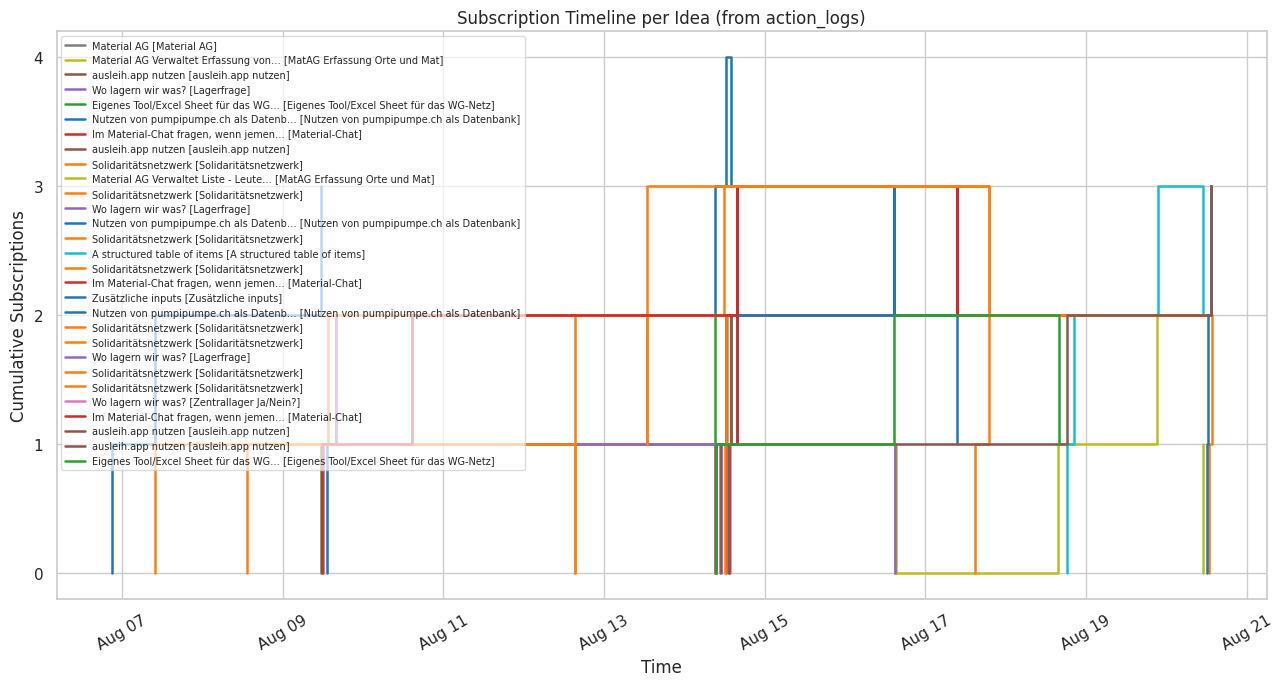

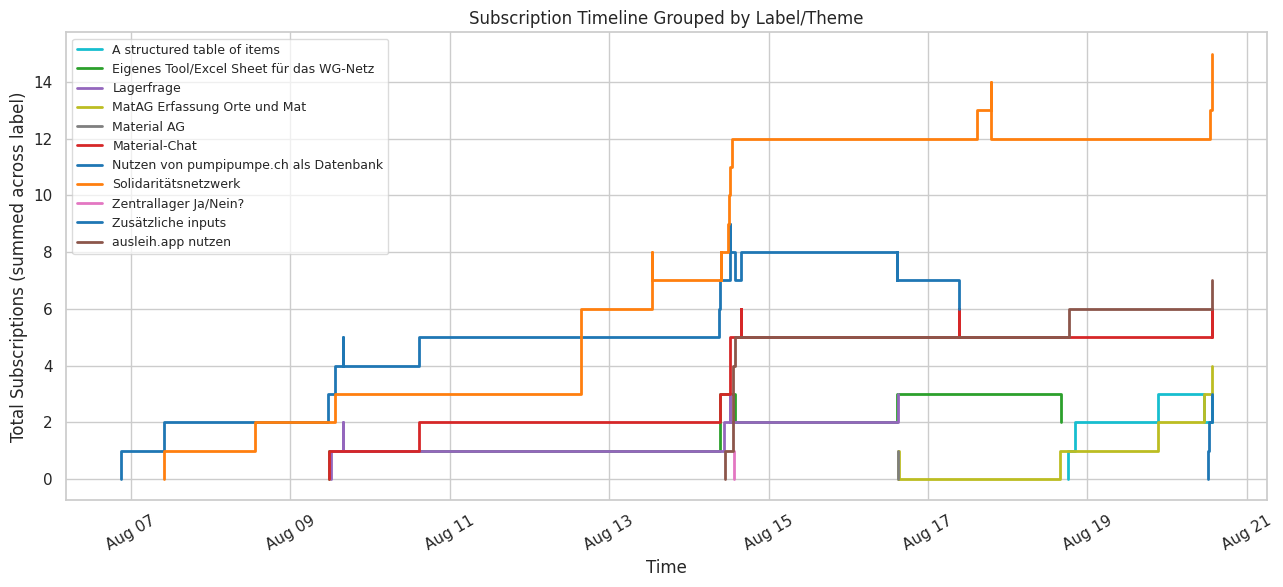

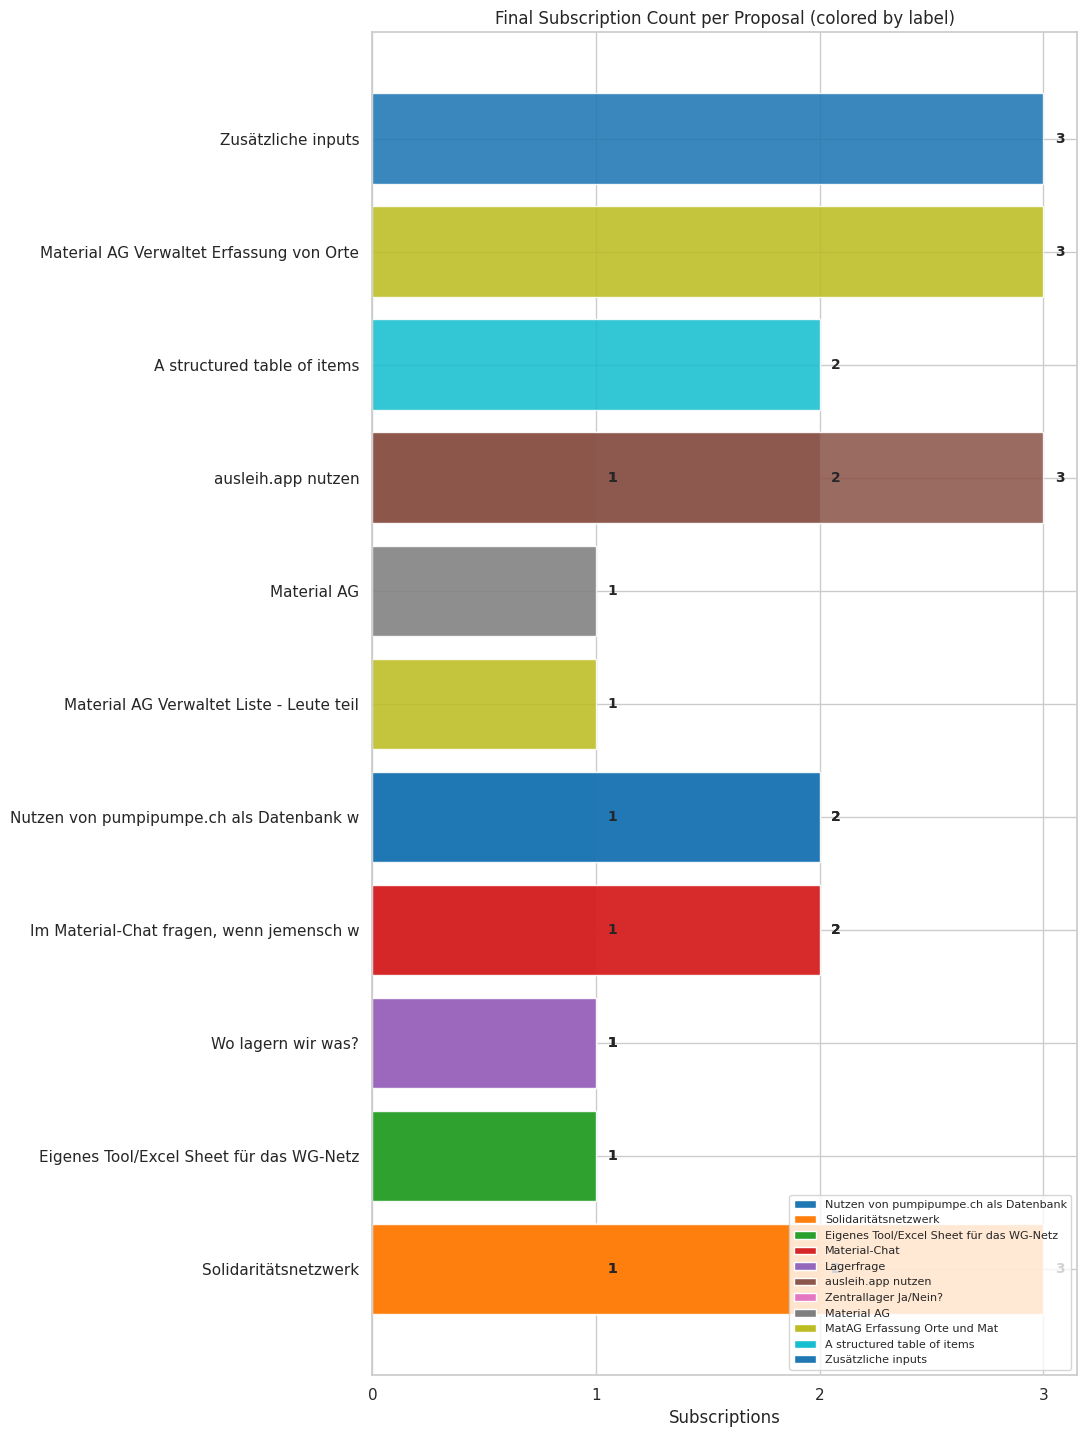

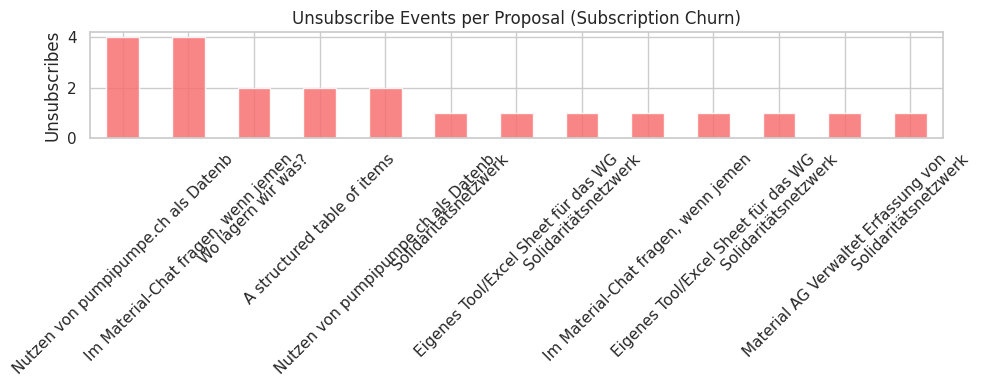

In [ ]:
# ── 6.1 Build subscription timeline from action_logs ─────────────────────────
# action_logs has full occurred_at timestamps for subscribe/unsubscribe
sub_events = df_actions[df_actions['action_type'].isin(['subscribe', 'unsubscribe'])].copy()
sub_events = sub_events.sort_values('occurred_at')

# Build id → title map
prop_title = dict(zip(df_proposals['id'], df_proposals['title']))
prop_label = dict(zip(df_proposals['id'], df_proposals['label_name']))

# Track per-proposal cumulative subscriptions over time
proposal_ids = set(df_proposals['id'])
support_over_time = {pid: [] for pid in proposal_ids}  # list of (timestamp, cumulative)
current_support = {pid: 0 for pid in proposal_ids}
user_sub_state = {}  # (user, proposal_id) → bool

# First seed with proposal creation timestamps at 0
for _, p in df_proposals.sort_values('created').iterrows():
    support_over_time[p['id']].append((p['created'], 0))

for _, ev in sub_events.iterrows():
    pid = ev['target_id']
    if pid not in proposal_ids:
        continue
    key = (ev['user'], pid)
    was_subbed = user_sub_state.get(key, False)
    if ev['action_type'] == 'subscribe' and not was_subbed:
        current_support[pid] += 1
        user_sub_state[key] = True
    elif ev['action_type'] == 'unsubscribe' and was_subbed:
        current_support[pid] = max(0, current_support[pid] - 1)
        user_sub_state[key] = False
    support_over_time[pid].append((ev['occurred_at'], current_support[pid]))

# ── 6.2 Timeline per idea ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))
cmap = plt.cm.tab10
label_colors = {lbl: cmap(i % 10) for i, lbl in enumerate(df_proposals['label_name'].unique())}

for pid, events in support_over_time.items():
    if not events:
        continue
    times, vals = zip(*events)
    lbl = prop_label.get(pid, 'Unlabelled')
    title_short = prop_title.get(pid, pid)[:35] + ('…' if len(prop_title.get(pid,'')) > 35 else '')
    ax.step(times, vals, where='post', linewidth=1.8,
            color=label_colors[lbl], label=f"{title_short} [{lbl}]")

ax.set_title('Subscription Timeline per Idea (from action_logs)')
ax.set_xlabel('Time')
ax.set_ylabel('Cumulative Subscriptions')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.xticks(rotation=30)
ax.legend(loc='upper left', fontsize=7, ncol=1, framealpha=0.7)
plt.tight_layout()
plt.show()

# ── 6.3 Timeline grouped by label ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

# Aggregate per label: at each subscribe/unsubscribe event, sum current support across label
label_groups = df_proposals.groupby('label_name')['id'].apply(list)

for lbl, pids in label_groups.items():
    # Collect all events for this label
    all_events = []
    for pid in pids:
        for t, _ in support_over_time.get(pid, []):
            # At time t, compute total across label
            all_events.append(t)

    if not all_events:
        continue
    all_events = sorted(set(all_events))
    times_lbl, vals_lbl = [], []
    for t in all_events:
        # Sum latest subscription count for each proposal at time t
        total = 0
        for pid in pids:
            evts = support_over_time.get(pid, [])
            # Latest value at or before t
            v = 0
            for et, ev in evts:
                if et <= t:
                    v = ev
            total += v
        times_lbl.append(t)
        vals_lbl.append(total)

    ax.step(times_lbl, vals_lbl, where='post', linewidth=2,
            color=label_colors[lbl], label=lbl)

ax.set_title('Subscription Timeline Grouped by Label/Theme')
ax.set_xlabel('Time')
ax.set_ylabel('Total Subscriptions (summed across label)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.xticks(rotation=30)
ax.legend(fontsize=9, framealpha=0.7)
plt.tight_layout()
plt.show()

# ── 6.4 Final subscription distribution ───────────────────────────────────────
df_subs = df_proposals[['title', 'label_name', 'subscription_count']].copy()
df_subs = df_subs.sort_values('subscription_count', ascending=True)
df_subs['title_short'] = df_subs['title'].str[:40]

fig, ax = plt.subplots(figsize=(11, max(4, len(df_subs) * 0.5)))
bar_colors = [label_colors.get(lbl, 'grey') for lbl in df_subs['label_name']]
bars = ax.barh(df_subs['title_short'], df_subs['subscription_count'],
               color=bar_colors, alpha=0.88)
for bar, val in zip(bars, df_subs['subscription_count']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='bold')
ax.set_title('Final Subscription Count per Proposal (colored by label)')
ax.set_xlabel('Subscriptions')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in label_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

# ── 6.5 Subscription churn ────────────────────────────────────────────────────
unsub_events = sub_events[sub_events['action_type'] == 'unsubscribe']
if not unsub_events.empty:
    unsub_by_prop = unsub_events.groupby('target_id').size()
    unsub_by_prop.index = [prop_title.get(pid, pid)[:35] for pid in unsub_by_prop.index]
    unsub_by_prop = unsub_by_prop.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 4))
    unsub_by_prop.plot(kind='bar', ax=ax, color='#f87171', alpha=0.85)
    ax.set_title('Unsubscribe Events per Proposal (Subscription Churn)')
    ax.set_ylabel('Unsubscribes')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No unsubscribe events recorded.")

## 7. Proposal Engagement Funnel

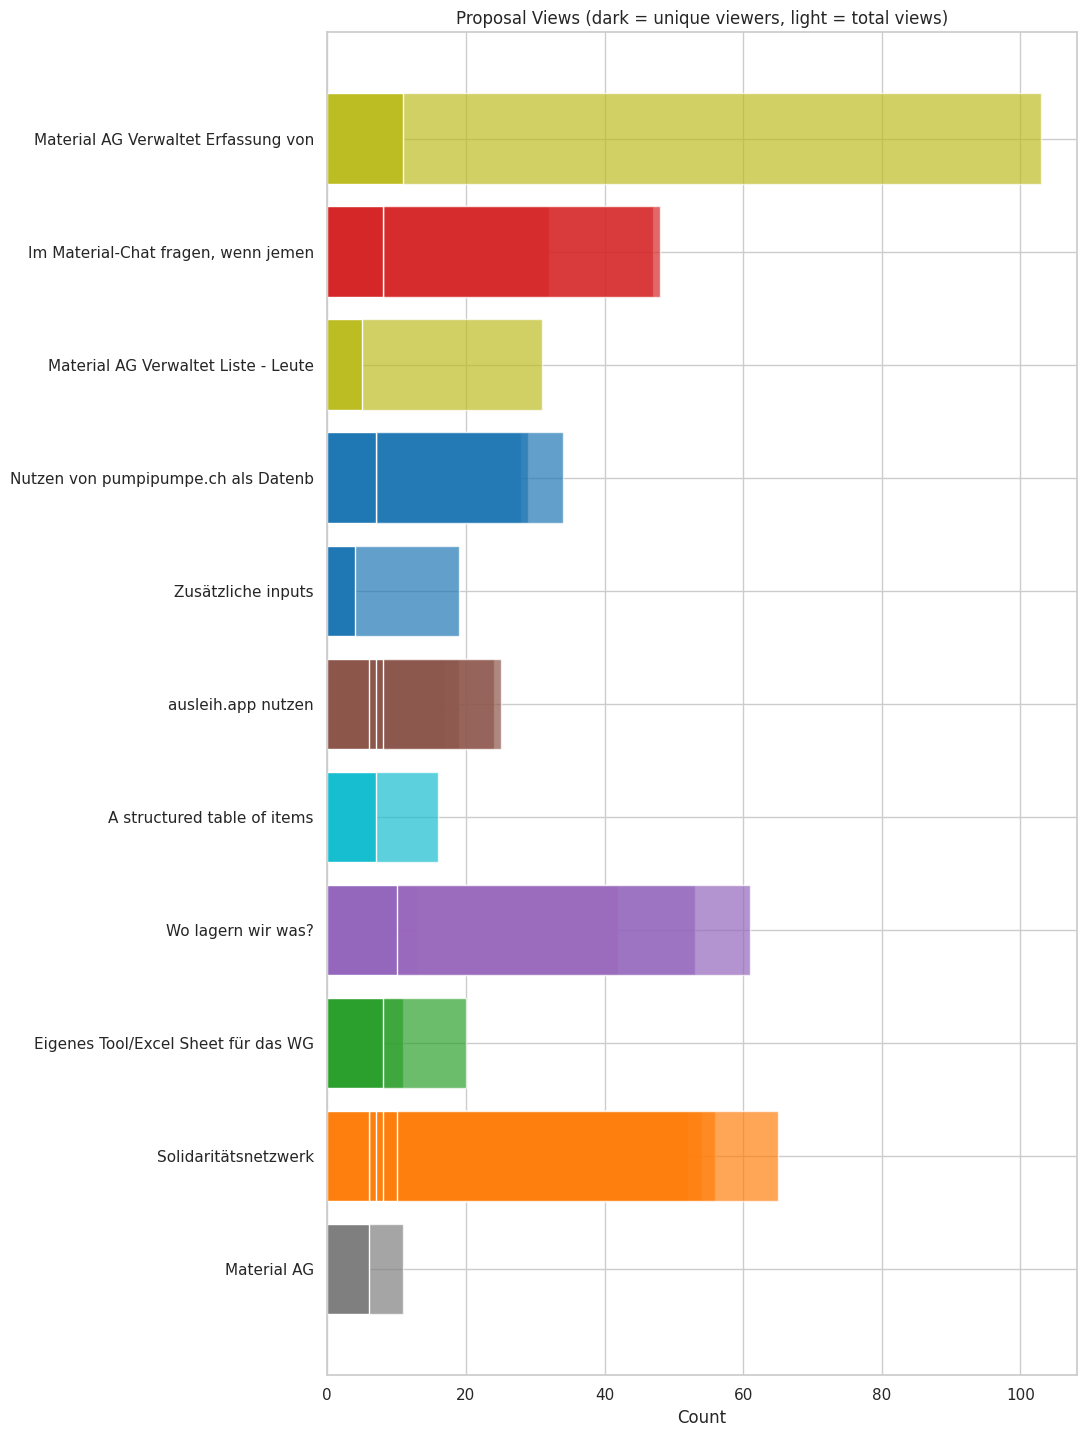

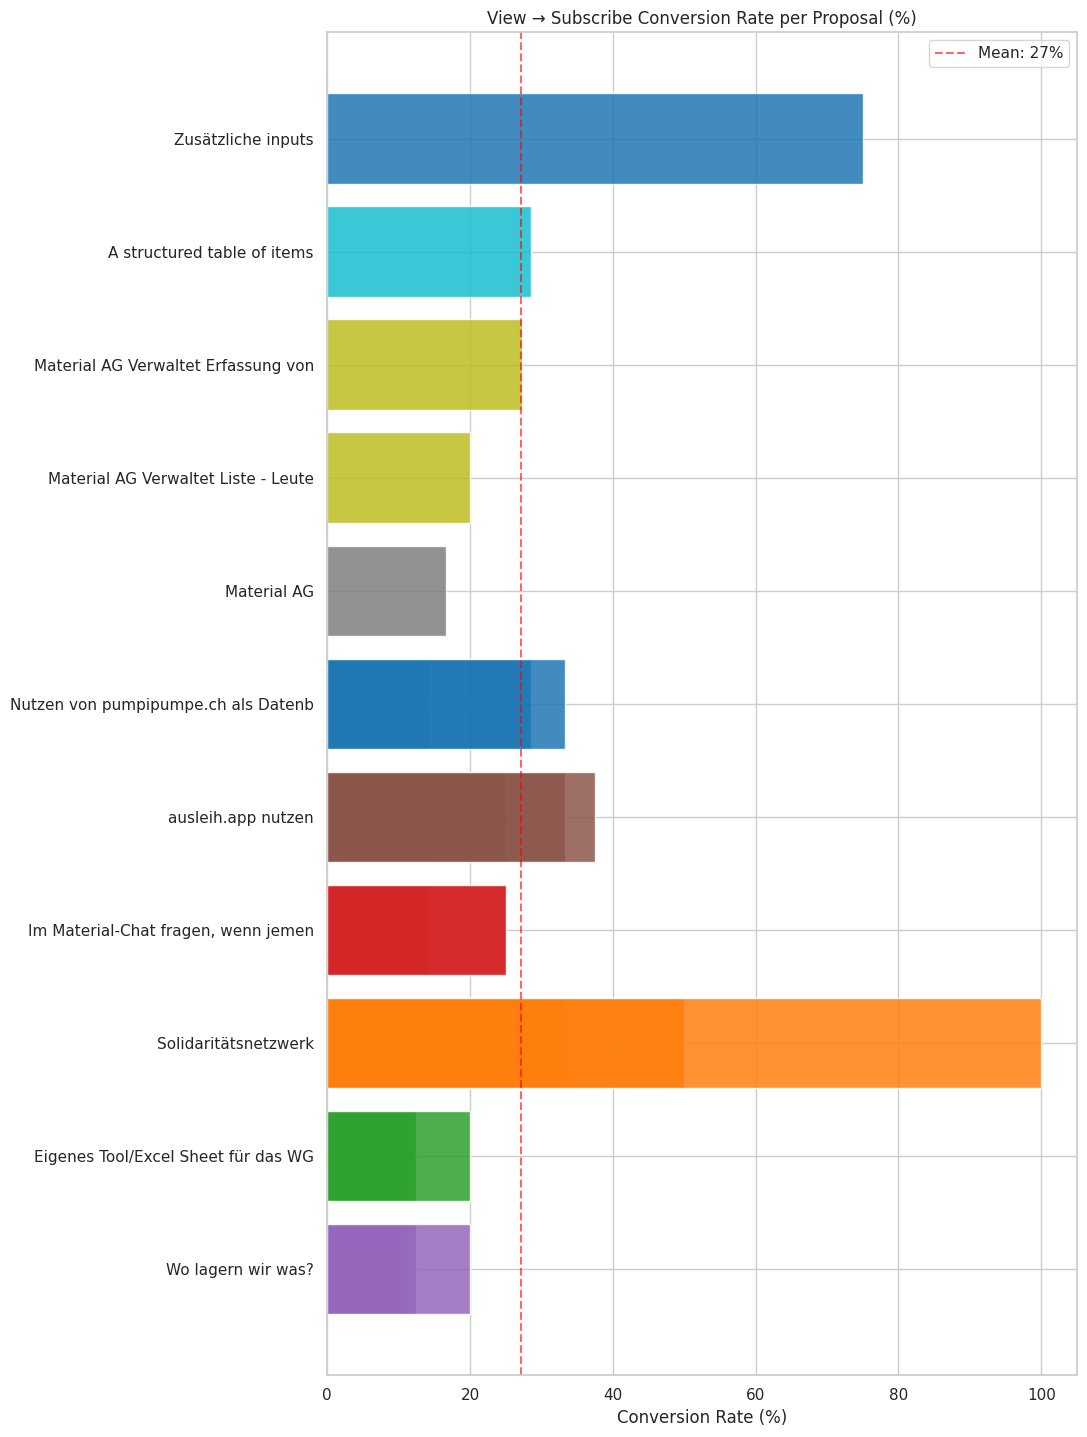

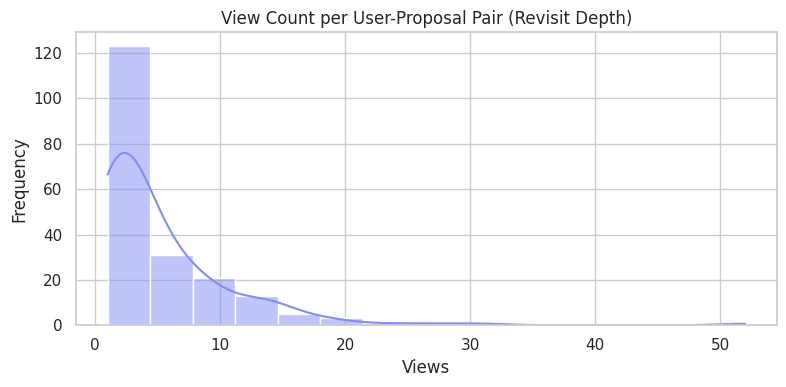

View depth — mean: 5.3, median: 3, max: 52

=== Proposal Hides (15 total) ===
ausleih.app nutzen                     1
Solidaritätsnetzwerk                   1
ausleih.app nutzen                     1
Nutzen von pumpipumpe.ch als Datenb    1
ausleih.app nutzen                     1
Eigenes Tool/Excel Sheet für das WG    1
Solidaritätsnetzwerk                   1
Wo lagern wir was?                     1
Im Material-Chat fragen, wenn jemen    1
Im Material-Chat fragen, wenn jemen    1
Nutzen von pumpipumpe.ch als Datenb    1
Nutzen von pumpipumpe.ch als Datenb    1
Solidaritätsnetzwerk                   1
Solidaritätsnetzwerk                   1
Solidaritätsnetzwerk                   1


In [ ]:
# ── 7.1 Views per proposal ────────────────────────────────────────────────────
if not df_views.empty:
    # Aggregate total views and unique viewers per proposal
    view_agg = df_views.groupby('proposal').agg(
        total_views=('view_count', 'sum'),
        unique_viewers=('user', 'nunique')
    ).reset_index()
    view_agg['title_short'] = view_agg['proposal'].map(
        lambda p: prop_title.get(p, p)[:35])
    view_agg['label'] = view_agg['proposal'].map(
        lambda p: prop_label.get(p, 'Unlabelled'))
    view_agg = view_agg.sort_values('total_views', ascending=True)

    fig, ax = plt.subplots(figsize=(11, max(4, len(view_agg) * 0.5)))
    bar_colors_v = [label_colors.get(l, 'grey') for l in view_agg['label']]
    ax.barh(view_agg['title_short'], view_agg['total_views'],
            color=bar_colors_v, alpha=0.7, label='Total Views')
    ax.barh(view_agg['title_short'], view_agg['unique_viewers'],
            color=bar_colors_v, alpha=1.0, label='Unique Viewers')
    ax.set_title('Proposal Views (dark = unique viewers, light = total views)')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()

    # ── 7.2 View → Subscribe conversion ─────────────────────────────────────
    subs_by_prop = df_proposals.set_index('id')['subscription_count']
    view_agg['subscriptions'] = view_agg['proposal'].map(subs_by_prop).fillna(0)
    view_agg['conversion_rate'] = (view_agg['subscriptions'] / view_agg['unique_viewers']).clip(0, 1)

    fig, ax = plt.subplots(figsize=(11, max(4, len(view_agg) * 0.5)))
    view_agg_sorted = view_agg.sort_values('conversion_rate', ascending=True)
    ax.barh(view_agg_sorted['title_short'], view_agg_sorted['conversion_rate'] * 100,
            color=[label_colors.get(l, 'grey') for l in view_agg_sorted['label']], alpha=0.85)
    ax.set_title('View → Subscribe Conversion Rate per Proposal (%)')
    ax.set_xlabel('Conversion Rate (%)')
    ax.axvline(x=view_agg_sorted['conversion_rate'].mean() * 100,
               color='red', linestyle='--', alpha=0.6, label=f"Mean: {view_agg_sorted['conversion_rate'].mean()*100:.0f}%")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ── 7.3 View depth ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(df_views['view_count'], bins=15, kde=True, ax=ax, color='#818cf8')
    ax.set_title('View Count per User-Proposal Pair (Revisit Depth)')
    ax.set_xlabel('Views')
    ax.set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()
    print(f"View depth — mean: {df_views['view_count'].mean():.1f}, "
          f"median: {df_views['view_count'].median():.0f}, "
          f"max: {df_views['view_count'].max()}")

# ── 7.4 Proposal hides ────────────────────────────────────────────────────────
if not df_hides.empty:
    hide_counts = df_hides.groupby('proposal').size()
    hide_counts.index = [prop_title.get(p, p)[:35] for p in hide_counts.index]
    print(f"\n=== Proposal Hides ({len(df_hides)} total) ===")
    print(hide_counts.sort_values(ascending=False).to_string())

## 8. Phase-Aware Analysis

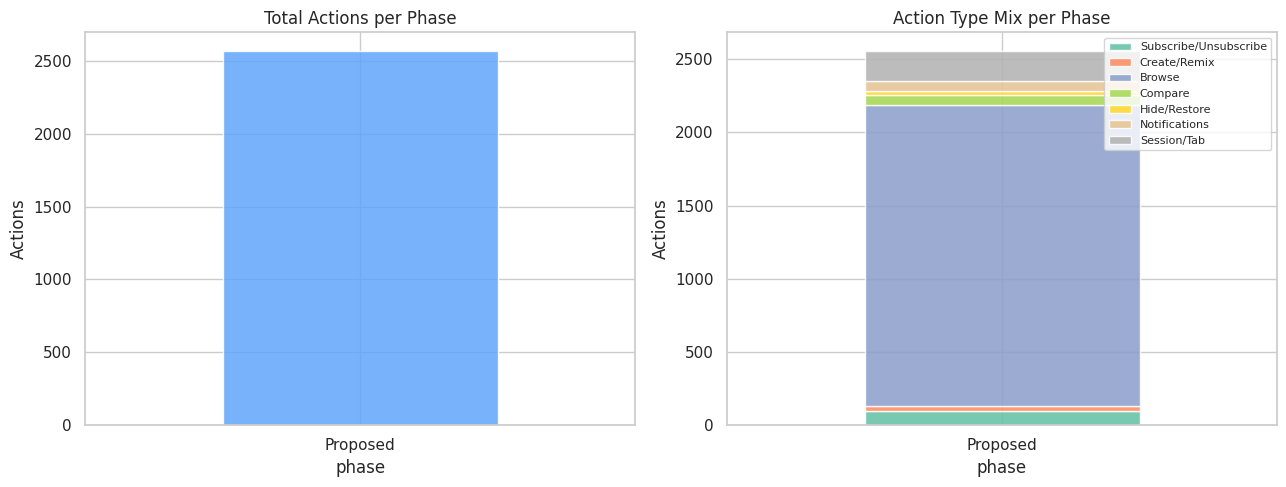

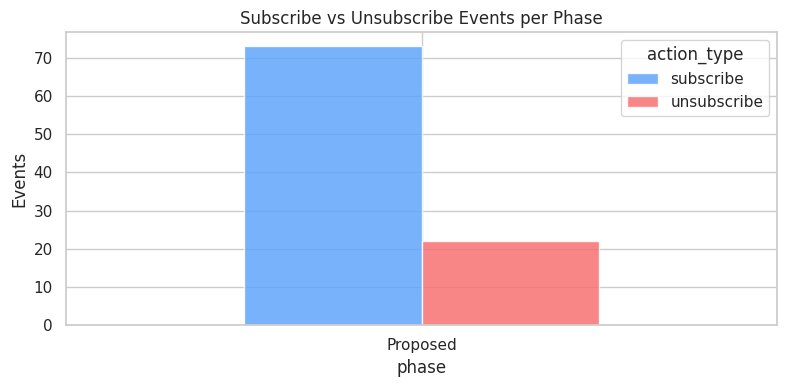

In [ ]:
# Assign each action to a phase
def assign_phase(ts):
    if df_phases.empty:
        return 'Unknown'
    for _, phase in df_phases.sort_values('started_at').iterrows():
        start = phase['started_at']
        end = phase['ended_at']
        if ts >= start and (pd.isna(end) or ts < end):
            return phase['phase_name']
    return 'Unknown'

df_actions['phase'] = df_actions['occurred_at'].apply(assign_phase)

# ── 8.1 Action volume per phase ───────────────────────────────────────────────
phase_counts = df_actions.groupby('phase').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
phase_colors_list = ['#60a5fa', '#f59e0b', '#34d399', '#a78bfa']
phase_counts.plot(kind='bar', ax=axes[0],
                  color=phase_colors_list[:len(phase_counts)], alpha=0.85)
axes[0].set_title('Total Actions per Phase')
axes[0].set_ylabel('Actions')
axes[0].tick_params(axis='x', rotation=0)

# ── 8.2 Action type mix per phase ─────────────────────────────────────────────
phase_action_mix = df_actions.groupby(['phase', 'action_type']).size().unstack(fill_value=0)
# Simplify: bucket action types
buckets = {
    'Subscribe/Unsubscribe': ['subscribe', 'unsubscribe'],
    'Create/Remix': ['create_idea', 'remix_singular', 'create_label'],
    'Browse': ['page_view', 'proposal_view', 'feed_filter_change'],
    'Compare': ['compare_open', 'compare_add', 'compare_remove'],
    'Hide/Restore': ['hide_proposal', 'restore_proposal'],
    'Notifications': ['notification_panel_open', 'notification_panel_click',
                      'notification_panel_dismiss', 'push_notification_click'],
    'Session/Tab': ['session_start', 'tab_switch'],
}
bucketed = {}
for bucket, atypes in buckets.items():
    cols = [c for c in atypes if c in phase_action_mix.columns]
    if cols:
        bucketed[bucket] = phase_action_mix[cols].sum(axis=1)

bucketed_df = pd.DataFrame(bucketed)
if not bucketed_df.empty:
    bucketed_df.plot(kind='bar', stacked=True, ax=axes[1], alpha=0.88,
                     colormap='Set2')
    axes[1].set_title('Action Type Mix per Phase')
    axes[1].set_ylabel('Actions')
    axes[1].legend(loc='upper right', fontsize=8)
    axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ── 8.3 Subscription events per phase ────────────────────────────────────────
sub_by_phase = df_actions[df_actions['action_type'].isin(['subscribe','unsubscribe'])]\
    .groupby(['phase','action_type']).size().unstack(fill_value=0)
if not sub_by_phase.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    sub_by_phase.plot(kind='bar', ax=ax, color=['#60a5fa', '#f87171'], alpha=0.85)
    ax.set_title('Subscribe vs Unsubscribe Events per Phase')
    ax.set_ylabel('Events')
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()

## 9. Final Outcomes & Consensus

Champion proposals (11 total):
  [3 subscriptions | Solidaritätsnetzwerk] ★ IN FOCUS
    Solidaritätsnetzwerk
  [3 subscriptions | Zusätzliche inputs] ★ IN FOCUS
    Zusätzliche inputs
  [3 subscriptions | ausleih.app nutzen] ★ IN FOCUS
    ausleih.app nutzen
  [3 subscriptions | MatAG Erfassung Orte und Mat] ★ IN FOCUS
    Material AG Verwaltet Erfassung von Orten und Mat
  [2 subscriptions | Material-Chat] ★ IN FOCUS
    Im Material-Chat fragen, wenn jemensch was braucht
  [2 subscriptions | Nutzen von pumpipumpe.ch als Datenbank] ★ IN FOCUS
    Nutzen von pumpipumpe.ch als Datenbank was wo vorhanden ist
  [2 subscriptions | A structured table of items] ★ IN FOCUS
    A structured table of items
  [1 subscriptions | Lagerfrage]
    Wo lagern wir was?
  [1 subscriptions | Eigenes Tool/Excel Sheet für das WG-Netz]
    Eigenes Tool/Excel Sheet für das WG-Netz Material erstellen
  [1 subscriptions | Material AG]
    Material AG
  [1 subscriptions | Zentrallager Ja/Nein?]
    Wo lagern wi

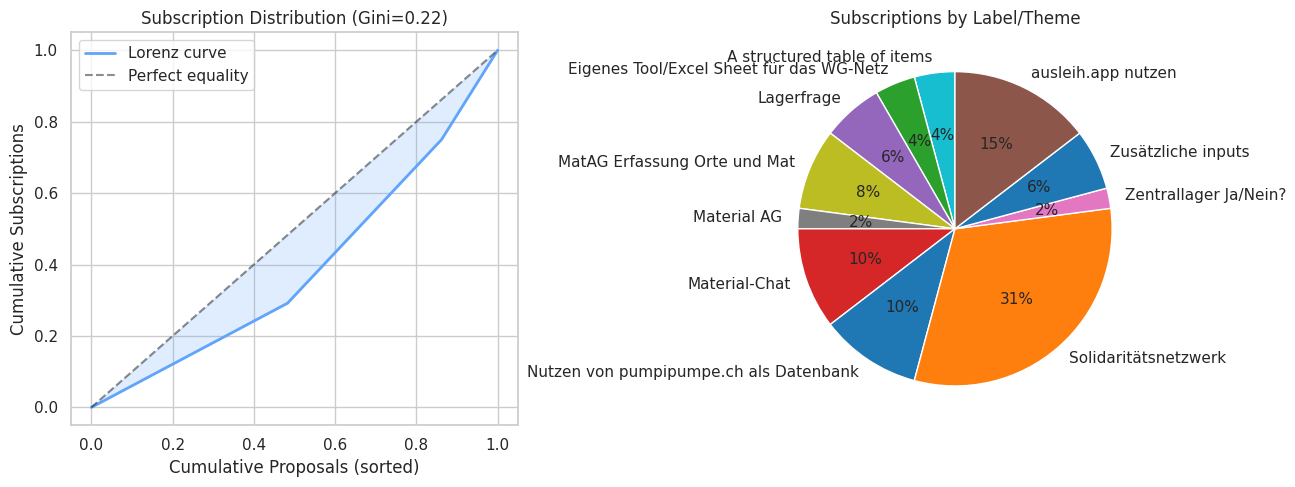

In [ ]:
# ── 9.1 Champions & focus set ─────────────────────────────────────────────────
# Fix: use subscription_count, not support_count
champions = df_proposals[df_proposals['is_champion'] == True].sort_values(
    'subscription_count', ascending=False)
focus_set = df_proposals[df_proposals['in_focus'] == True].sort_values(
    'subscription_count', ascending=False)

print("=" * 60)
print(f"Champion proposals ({len(champions)} total):")
print("=" * 60)
for _, row in champions.iterrows():
    focus_marker = " ★ IN FOCUS" if row['in_focus'] else ""
    print(f"  [{row['subscription_count']} subscriptions | {row['label_name']}]{focus_marker}")
    print(f"    {row['title']}")

# ── 9.2 Consensus metrics ──────────────────────────────────────────────────────
subs = df_proposals['subscription_count'].values.astype(float)
total_subs = subs.sum()

if total_subs > 0:
    # Gini coefficient
    n = len(subs)
    subs_sorted = np.sort(subs)
    cumsum = np.cumsum(subs_sorted)
    gini = (2 * np.sum((np.arange(1, n+1)) * subs_sorted) - (n+1) * cumsum[-1]) / (n * cumsum[-1])

    # Effective proposal count (inverse Simpson / 1/HHI)
    proportions = subs / total_subs
    hhi = np.sum(proportions ** 2)
    effective_count = 1 / hhi if hhi > 0 else 0

    print(f"\n=== Consensus Metrics ===")
    print(f"  Total subscriptions: {int(total_subs)}")
    print(f"  Gini coefficient:    {gini:.3f} (0=equal, 1=concentrated)")
    print(f"  Effective proposals: {effective_count:.1f} (out of {len(subs)})")
    print(f"  Props with subs > 0: {int((subs > 0).sum())}")

    # Lorenz curve
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    lorenz = np.concatenate([[0], cumsum / total_subs])
    axes[0].plot(np.linspace(0, 1, len(lorenz)), lorenz, color='#60a5fa', linewidth=2, label='Lorenz curve')
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect equality')
    axes[0].fill_between(np.linspace(0, 1, len(lorenz)), lorenz,
                          np.linspace(0, 1, len(lorenz)), alpha=0.2, color='#60a5fa')
    axes[0].set_title(f'Subscription Distribution (Gini={gini:.2f})')
    axes[0].set_xlabel('Cumulative Proposals (sorted)')
    axes[0].set_ylabel('Cumulative Subscriptions')
    axes[0].legend()

    # Label-aggregated subscriptions pie
    label_subs = df_proposals.groupby('label_name')['subscription_count'].sum()
    label_subs.plot.pie(ax=axes[1], autopct='%1.0f%%', startangle=90,
                         colors=[label_colors.get(l, 'grey') for l in label_subs.index])
    axes[1].set_title('Subscriptions by Label/Theme')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()
else:
    print("No subscriptions recorded.")

## 10. Post-Study Survey Analysis

SUS (System Usability Scale) items use a 5-point Likert scale (1–5). The SUS score is computed as:
- Odd items (1,3,5,7,9): score − 1
- Even items (2,4,6,8,10): 5 − score
- SUS = sum × 2.5 (range 0–100)

Survey responses: 3

=== SUS Scores ===
  Mean:   51.7
  Median: 45.0
  Range:  35 – 75
  (>68 = above average usability)


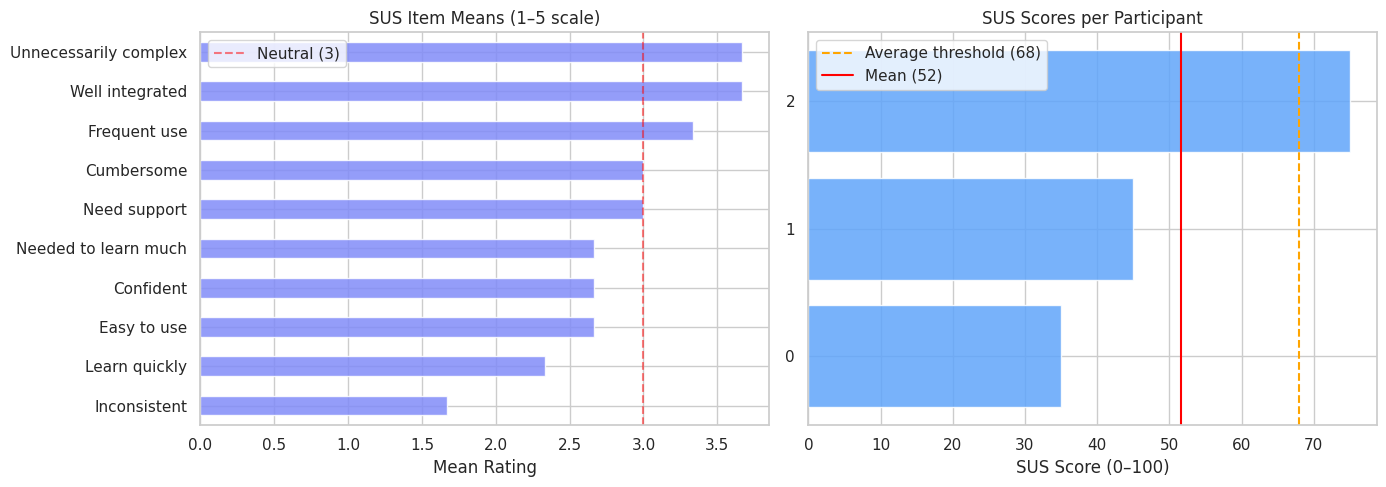


=== Qualitative Feedback ===

--- Building On Ideas ---
  P1: Das remixen brauchte eine kurze Eingewöhnungsphase, ging dann aber recht leicht von der Hand. Die richtige Sprache zu finden fand ich herausfordernd. Kurze prägnante Aussagen sind übersichtlicher, können aber evtl nicht die gesamte Komplexität eines Problems darstellen. Bei zu langen Beiträgen wird das Vergleichen und das Nachvollziehen von Veränderungen beim remixen sehr aufwändig und unübersichtlich.
Ich bin mir nicht sicher ob ich das Labelsystem ausreichend verstanden und genutzt habe.
  P2: Ja das war einfach. Meiner Meinung nach die beste Funktion
  P3: Ja 

--- Convergence Process ---
  P1: Unterstützt hat sicher die Vergleichs und Remix-Funktion, sowie die grafische Darstellung. Teilweise wäre es nützlich gewesen mehr als 2 Ideen in einer Lösung zusammenzubringen. Dies in mehreren Teilschritten tun zu müssen war umständlich und sorgte für eine unübersichtlichere grafische Darstellung. Teilweise fanden nicht nachvoll

In [ ]:
if df_surveys.empty:
    print("No survey data available for this group yet.")
else:
    # Parse responses JSON
    survey_data = []
    for _, row in df_surveys.iterrows():
        try:
            resp = json.loads(row['responses']) if isinstance(row['responses'], str) else row['responses']
            resp['user'] = row.get('user', '')
            survey_data.append(resp)
        except Exception as e:
            print(f"Error parsing survey: {e}")

    if not survey_data:
        print("No parseable survey responses found.")
    else:
        df_resp = pd.DataFrame(survey_data)
        print(f"Survey responses: {len(df_resp)}")

        # ── SUS Score ────────────────────────────────────────────────────────────
        sus_cols = [f'sus_{i}' for i in range(1, 11)]
        sus_present = [c for c in sus_cols if c in df_resp.columns]

        if len(sus_present) == 10:
            def compute_sus(row):
                total = 0
                for i in range(1, 11):
                    val = row.get(f'sus_{i}', 3)
                    if i % 2 == 1:  # odd: score - 1
                        total += (val - 1)
                    else:           # even: 5 - score
                        total += (5 - val)
                return total * 2.5

            df_resp['sus_score'] = df_resp.apply(compute_sus, axis=1)

            print(f"\n=== SUS Scores ===")
            print(f"  Mean:   {df_resp['sus_score'].mean():.1f}")
            print(f"  Median: {df_resp['sus_score'].median():.1f}")
            print(f"  Range:  {df_resp['sus_score'].min():.0f} – {df_resp['sus_score'].max():.0f}")
            print(f"  (>68 = above average usability)")

            # SUS breakdown per item
            sus_means = df_resp[sus_present].mean()
            sus_labels = [
                'Frequent use', 'Unnecessarily complex', 'Easy to use',
                'Need support', 'Well integrated', 'Inconsistent',
                'Learn quickly', 'Cumbersome', 'Confident', 'Needed to learn much'
            ]
            sus_means.index = sus_labels[:len(sus_means)]

            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            # Per-item means
            sus_means.sort_values().plot(kind='barh', ax=axes[0], color='#818cf8', alpha=0.85)
            axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.5, label='Neutral (3)')
            axes[0].set_title('SUS Item Means (1–5 scale)')
            axes[0].set_xlabel('Mean Rating')
            axes[0].legend()

            # Overall SUS score distribution
            axes[1].barh(range(len(df_resp)), df_resp['sus_score'].sort_values(),
                         color='#60a5fa', alpha=0.85)
            axes[1].axvline(x=68, color='orange', linestyle='--', label='Average threshold (68)')
            axes[1].axvline(x=df_resp['sus_score'].mean(), color='red',
                            linestyle='-', label=f"Mean ({df_resp['sus_score'].mean():.0f})")
            axes[1].set_title('SUS Scores per Participant')
            axes[1].set_xlabel('SUS Score (0–100)')
            axes[1].set_yticks(range(len(df_resp)))
            axes[1].legend()

            plt.tight_layout()
            plt.show()

        # ── Qualitative responses ─────────────────────────────────────────────
        text_cols = [c for c in df_resp.columns
                     if c not in sus_present + ['user', 'sus_score']
                     and df_resp[c].dtype == object]

        if text_cols:
            print("\n=== Qualitative Feedback ===")
            for col in text_cols:
                print(f"\n--- {col.replace('_', ' ').title()} ---")
                for i, val in enumerate(df_resp[col].dropna()):
                    if val and str(val).strip():
                        print(f"  P{i+1}: {val}")

## 11. Extended Metrics — Label Diversity, Temporal Convergence & Behavioral Analysis

This section uses the extended metrics engine added in August 2026.
It computes three new metric categories for the WG study data:
- **Label metrics** — coverage, diversity, and support distribution per label
- **Temporal convergence** — how quickly the group converged on a few proposals
- **Behavioral metrics** — action composition, retraction rate, cross-cluster engagement, dissatisfaction


In [ ]:
from collections import defaultdict

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



def _json_list(value):
    if isinstance(value, list):
        return [str(item) for item in value if pd.notna(item)]
    if value is None or value == "" or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            if isinstance(parsed, list):
                return [str(item) for item in parsed if pd.notna(item)]
        except Exception:
            return [value]
    return []



def _json_object(value):
    if isinstance(value, dict):
        return value
    if value is None or value == "" or (isinstance(value, float) and pd.isna(value)):
        return {}
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            if isinstance(parsed, dict):
                return parsed
        except Exception:
            return {}
    return {}



def _parse_ts(value):
    ts = pd.to_datetime(value, utc=True, errors="coerce")
    if pd.isna(ts):
        return 0.0
    return float(ts.timestamp())



def _gini(values):
    arr = np.array([float(v) for v in values], dtype=float)
    if arr.size == 0:
        return 0.0
    if np.all(arr == 0):
        return 0.0
    arr = np.sort(arr)
    n = arr.size
    index = np.arange(1, n + 1, dtype=float)
    return float((2 * np.sum(index * arr) / np.sum(arr) - (n + 1)) / n)



def _build_label_lists():
    label_lists = []
    for _, row in df_proposals.iterrows():
        labels = _json_list(row.get("labels", []))
        if not labels:
            primary_label = row.get("primary_label", "")
            if pd.notna(primary_label) and str(primary_label):
                labels = [str(primary_label)]
        label_lists.append(labels)
    return label_lists



def compute_label_metrics_local():
    label_lists = _build_label_lists()
    all_labels = [label for labels in label_lists for label in labels]
    total_solutions = len(df_proposals)
    solutions_with_labels = sum(1 for labels in label_lists if labels)
    label_coverage = solutions_with_labels / max(1, total_solutions)

    labels_per_sol = [len(labels) for labels in label_lists]
    label_support = defaultdict(int)
    label_usage_count = defaultdict(int)
    for labels, (_, row) in zip(label_lists, df_proposals.iterrows()):
        support = int(row.get("subscription_count", row.get("support_count", 0)) or 0)
        for label in labels:
            label_support[label] += support
        for label in set(labels):
            label_usage_count[label] += 1

    orphan_label_count = sum(1 for count in label_usage_count.values() if count == 1)
    label_gini = _gini(label_support.values()) if label_support else 0.0
    top_labels = []
    for label_id, support in sorted(label_support.items(), key=lambda item: -item[1])[:10]:
        top_labels.append({
            "id": label_id,
            "name": label_name.get(label_id, label_id),
            "support": int(support),
            "proposal_count": int(label_usage_count.get(label_id, 0)),
        })

    return {
        "unique_labels": len(set(all_labels)),
        "label_coverage": round(label_coverage, 4),
        "labels_per_proposal_mean": round(float(np.mean(labels_per_sol)) if labels_per_sol else 0.0, 2),
        "label_gini": round(float(label_gini), 4),
        "orphan_label_count": int(orphan_label_count),
        "top_labels": top_labels,
    }



def compute_temporal_metrics_local(n_samples=12):
    events = []
    for v in df_votes.itertuples(index=False):
        ts = _parse_ts(getattr(v, "occurred_at", "") or getattr(v, "created", ""))
        if ts > 0:
            events.append((ts, str(getattr(v, "solution", "")), str(getattr(v, "user", "")), int(getattr(v, "vote", 0) or 0)))

    vote_log_types = {"vote_like": 1, "vote_repeal": 0}
    for log in df_actions.itertuples(index=False):
        action_type = str(getattr(log, "action_type", ""))
        ts = _parse_ts(getattr(log, "occurred_at", ""))
        if ts <= 0:
            continue
        if action_type in vote_log_types:
            events.append((ts, str(getattr(log, "target_id", "")), str(getattr(log, "user", "")), vote_log_types[action_type]))
        elif action_type == "vote_migration":
            metadata = _json_object(getattr(log, "metadata_json", {}))
            from_sid = metadata.get("from_solution")
            to_sid = metadata.get("to_solution")
            if from_sid:
                events.append((ts, str(from_sid), str(getattr(log, "user", "")), 0))
            if to_sid:
                events.append((ts, str(to_sid), str(getattr(log, "user", "")), 1))

    if not events:
        empty_curve = [{"t": round(i / max(1, n_samples - 1), 4), "gini": 0.0, "effective_count": 0.0} for i in range(n_samples)]
        return {
            "gini_curve": empty_curve,
            "convergence_step": -1,
            "convergence_speed": 0.0,
            "stability_index": 0.0,
        }

    events.sort(key=lambda item: item[0])
    t_min = events[0][0]
    t_max = events[-1][0]
    t_range = max(1.0, t_max - t_min)
    sample_times = [t_min + (i / max(1, n_samples - 1)) * t_range for i in range(n_samples)]
    sol_ids = {str(row.id) for row in df_proposals.itertuples(index=False)}
    user_votes = defaultdict(dict)
    support = {sid: 0 for sid in sol_ids}
    gini_curve = []
    ev_idx = 0

    for t_sample in sample_times:
        while ev_idx < len(events) and events[ev_idx][0] <= t_sample:
            _, sid, user, vote_val = events[ev_idx]
            if sid in sol_ids:
                old_val = user_votes[user].get(sid, 0)
                if old_val > 0 and vote_val == 0:
                    support[sid] = max(0, support[sid] - 1)
                elif old_val == 0 and vote_val > 0:
                    support[sid] += 1
                user_votes[user][sid] = vote_val
            ev_idx += 1

        values = list(support.values())
        gini = _gini(values)
        total = sum(values)
        if total > 0:
            proportions = [v / total for v in values if v > 0]
            hhi = sum(p ** 2 for p in proportions)
            effective_count = 1.0 / hhi if hhi > 0 else 0.0
        else:
            effective_count = 0.0
        progress = (t_sample - t_min) / t_range
        gini_curve.append({"t": round(progress, 4), "gini": round(gini, 4), "effective_count": round(effective_count, 2)})

    convergence_step = next((i for i, pt in enumerate(gini_curve) if pt["t"] >= 0.25 and pt["gini"] >= 0.5), -1)
    gini_values = np.array([pt["gini"] for pt in gini_curve], dtype=float)
    x_vals = np.arange(len(gini_values), dtype=float)
    if len(gini_values) >= 2 and gini_values.std() > 0:
        slope = float(np.polyfit(x_vals, gini_values, 1)[0])
    else:
        slope = 0.0
    stability = float(gini_values[-3:].std()) if len(gini_values) >= 3 else 0.0

    return {
        "gini_curve": gini_curve,
        "convergence_step": convergence_step,
        "convergence_speed": round(slope, 6),
        "stability_index": round(stability, 4),
    }



def compute_behavioral_metrics_local():
    action_bucket_map = {
        "root_solution": "create_root",
        "branch_solution": "create_remix",
        "merge_solution": "create_merge",
        "create_solution": "create_root",
        "vote_like": "vote_support",
        "vote_repeal": "vote_retract",
        "vote_migration": "vote_migrate",
        "accept_migration": "vote_migrate",
        "subscribe": "vote_support",
        "unsubscribe": "vote_retract",
        "focus_enter": "browse",
        "focus_exit": "browse",
    }

    action_counts = defaultdict(int)
    total_actions = 0
    for log in df_actions.itertuples(index=False):
        bucket = action_bucket_map.get(str(getattr(log, "action_type", "")), "other")
        if bucket == "browse":
            continue
        action_counts[bucket] += 1
        total_actions += 1

    action_composition = {
        bucket: round(cnt / max(1, total_actions), 4)
        for bucket, cnt in sorted(action_counts.items())
    }
    vote_events = action_counts.get("vote_support", 0) + action_counts.get("vote_retract", 0)
    retraction_rate = round(action_counts.get("vote_retract", 0) / max(1, vote_events), 4)

    sol_by_id = {str(row.id): row for row in df_proposals.itertuples(index=False)}
    cluster_attr = "cluster_key" if "cluster_key" in df_proposals.columns else ("cluster_id" if "cluster_id" in df_proposals.columns else None)
    user_support = defaultdict(lambda: defaultdict(int))
    for v in df_votes.itertuples(index=False):
        if int(getattr(v, "vote", 0) or 0) > 0:
            sid = str(getattr(v, "solution", ""))
            if sid in sol_by_id:
                user_support[str(getattr(v, "user", ""))][sid] += 1

    cross_cluster_votes = 0
    total_votes_counted = 0
    for user, sol_votes in user_support.items():
        if not sol_votes:
            continue
        home_sol = max(sol_votes, key=sol_votes.get)
        home_cluster = getattr(sol_by_id[home_sol], cluster_attr, "") if cluster_attr else ""
        for sid, cnt in sol_votes.items():
            total_votes_counted += cnt
            sol_cluster = getattr(sol_by_id[sid], cluster_attr, "") if cluster_attr else ""
            if sol_cluster and home_cluster and sol_cluster != home_cluster:
                cross_cluster_votes += cnt

    cross_cluster_engagement = round(cross_cluster_votes / max(1, total_votes_counted), 4)

    champion_ids = {str(row.id) for row in df_proposals.itertuples(index=False) if bool(getattr(row, "is_champion", False))}
    final_user_votes = defaultdict(dict)
    for v in sorted(df_votes.itertuples(index=False), key=lambda item: _parse_ts(getattr(item, "occurred_at", "") or getattr(item, "created", ""))):
        final_user_votes[str(getattr(v, "user", ""))][str(getattr(v, "solution", ""))] = int(getattr(v, "vote", 0) or 0)

    satisfied = 0
    dissatisfied = 0
    for votes in final_user_votes.values():
        supported_ids = {sid for sid, val in votes.items() if val > 0}
        if not supported_ids:
            continue
        if supported_ids & champion_ids:
            satisfied += 1
        else:
            dissatisfied += 1

    total_voters = satisfied + dissatisfied
    dissatisfaction_ratio = round(dissatisfied / max(1, total_voters), 4)

    return {
        "action_composition": action_composition,
        "retraction_rate": retraction_rate,
        "cross_cluster_engagement": cross_cluster_engagement,
        "dissatisfaction_ratio": dissatisfaction_ratio,
        "total_voting_actors": total_voters,
    }



def plot_temporal_convergence(question_data, output_path, gini_curve=None):
    curve = gini_curve if gini_curve is not None else temporal_m["gini_curve"]
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot([pt["t"] for pt in curve], [pt["gini"] for pt in curve], color="#60a5fa", linewidth=2, label="Gini")
    ax.plot([pt["t"] for pt in curve], [pt["effective_count"] for pt in curve], color="#f59e0b", linewidth=2, label="Effective count")
    ax.set_xlabel("Normalized Time")
    ax.set_ylabel("Metric Value")
    ax.set_title("Temporal Convergence")
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return output_path



def plot_label_distribution(question_data, output_path):
    top_labels = label_m["top_labels"]
    fig, ax = plt.subplots(figsize=(12, max(5, 0.35 * max(1, len(top_labels)))))
    if top_labels:
        labels = [item["name"] for item in top_labels][::-1]
        support = [item["support"] for item in top_labels][::-1]
        ax.barh(labels, support, color="#60a5fa", alpha=0.9)
        ax.set_xlabel("Total Support")
        ax.set_title("Label Distribution")
    else:
        ax.text(0.5, 0.5, "No label data available", transform=ax.transAxes, ha="center", va="center")
        ax.set_axis_off()
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return output_path


label_m = compute_label_metrics_local()
temporal_m = compute_temporal_metrics_local()
behavioral_m = compute_behavioral_metrics_local()
question_data = None

print('=== Label Metrics ===')
print(f"  unique_labels         : {label_m['unique_labels']}")
print(f"  label_coverage        : {label_m['label_coverage']:.1%}")
print(f"  labels_per_proposal   : {label_m['labels_per_proposal_mean']:.2f}")
print(f"  label_gini            : {label_m['label_gini']:.4f}")
print(f"  orphan_label_count    : {label_m['orphan_label_count']}")

print()
print('=== Temporal Convergence ===')
print(f"  convergence_step      : {temporal_m['convergence_step']} / {len(temporal_m['gini_curve'])-1}")
print(f"  convergence_speed     : {temporal_m['convergence_speed']:.6f} (slope of Gini)")
print(f"  stability_index       : {temporal_m['stability_index']:.4f} (std of last 3 Gini pts)")

print()
print('=== Behavioral Metrics ===')
print(f"  retraction_rate       : {behavioral_m['retraction_rate']:.1%}")
print(f"  cross_cluster_engage  : {behavioral_m['cross_cluster_engagement']:.1%}")
print(f"  dissatisfaction_ratio : {behavioral_m['dissatisfaction_ratio']:.1%}")
print(f"  action_composition    :")
for act, frac in behavioral_m['action_composition'].items():
    print(f"    {act:25s}: {frac:.1%}")


=== Label Metrics ===
  unique_labels         : 11
  label_coverage        : 100.0%
  labels_per_proposal   : 1.38
  label_gini            : 0.3049
  orphan_label_count    : 2

=== Temporal Convergence ===
  convergence_step      : -1 / 11
  convergence_speed     : 0.000000 (slope of Gini)
  stability_index       : 0.0000 (std of last 3 Gini pts)

=== Behavioral Metrics ===
  retraction_rate       : 23.2%
  cross_cluster_engage  : 0.0%
  dissatisfaction_ratio : 100.0%
  action_composition    :
    other                    : 96.3%
    vote_retract             : 0.9%
    vote_support             : 2.8%


In [ ]:
import pandas as pd

top_labels_df = pd.DataFrame(label_m['top_labels'])
if not top_labels_df.empty:
    top_labels_df = top_labels_df[['name', 'proposal_count', 'support']]
    top_labels_df.columns = ['Label', 'Proposals', 'Total Support']
    display(top_labels_df)
else:
    print('No label data available (label bug may still be active in this dataset)')


,Label,Proposals,Total Support
0,Solidaritätsnetzwerk,8,15
1,Lagerfrage,6,8
2,Nutzen von pumpipumpe.ch als Datenbank,5,7
3,ausleih.app nutzen,4,7
4,Eigenes Tool/Excel Sheet für das WG-Netz,4,6
5,Material-Chat,4,6
6,Material AG,3,5
7,MatAG Erfassung Orte und Mat,2,4
8,A structured table of items,2,3
9,Zusätzliche inputs,1,3


In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

_tmp_temporal = '/tmp/wg_temporal_convergence.png'
plot_temporal_convergence(question_data, _tmp_temporal, gini_curve=temporal_m['gini_curve'])
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(mpimg.imread(_tmp_temporal))
ax.axis('off')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1179149/1905337425.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
_tmp_labels = '/tmp/wg_label_distribution.png'
plot_label_distribution(question_data, _tmp_labels)
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(mpimg.imread(_tmp_labels))
ax.axis('off')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1179149/1364174002.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
gini_df = pd.DataFrame(temporal_m['gini_curve'])
gini_df.columns = ['Normalized Time', 'Gini', 'Effective Count']
gini_df['Normalized Time'] = gini_df['Normalized Time'].apply(lambda x: f'{x:.0%}')
display(gini_df)


,Normalized Time,Gini,Effective Count
0,0%,0.0,0.0
1,9%,0.0,0.0
2,18%,0.0,0.0
3,27%,0.0,0.0
4,36%,0.0,0.0
5,45%,0.0,0.0
6,55%,0.0,0.0
7,64%,0.0,0.0
8,73%,0.0,0.0
9,82%,0.0,0.0
